# Classificador de Criticidade de Bugs — Sistema Híbrido por Stacking

> **Disciplina:** Reconhecimento de Padrões — UPE, 1º Período  
> **Base na literatura:** Lamkanfi et al. (2010) — *Predicting the Severity of a Reported Bug*  
> **Proposta:** Sistema Híbrido via *Stacking* (meta-learning) com TF-IDF + Embeddings LLM

---

## O problema

Dado o **texto** de um relatório de bug ou vulnerabilidade CVE, classificar sua
**criticidade** em três níveis: **Alta**, **Média** ou **Baixa**.

Bug trackers como o Jira do Apache Spark acumulam dezenas de milhares de itens.
Automatizar a triagem economiza horas de revisão manual e prioriza o que realmente
precisa de atenção imediata.

## O que Lamkanfi et al. (2010) fizeram

Treinaram classificadores clássicos (Naive Bayes, SVM, Decision Tree, k-NN) com
representação **bag-of-words** nos projetos Eclipse e Mozilla.

## Nossa extensão

| Dimensão | Lamkanfi (2010) | Este trabalho |
|---|---|---|
| Representação | Bag-of-words | TF-IDF sublinear **+** embeddings Qwen3 |
| Classificador | Modelos independentes | **Stacking** (meta-learning) |
| Datasets | Eclipse, Mozilla | Apache Spark + CIRCL CVE |
| Desbalanceamento | Não tratado | SMOTE dentro do fold de treino |

## Estrutura do notebook

| Seção | Conteúdo |
|---|---|
| 1. Dados | Carregamento Spark e CIRCL, mapeamento de rótulos |
| 2. EDA | Distribuição de classes, comprimento dos textos |
| 3. Pré-processamento | Limpeza de texto, análise de tokens, n-gramas, TF-IDF visual |
| 4. Balanceamento | Undersampling real-first + SMOTE dentro do fold |
| 5. Embeddings | Qwen3-0.6B com cache em disco |
| 6. Framework | Validação cruzada, todas as métricas |
| 7. Baselines | NB, LogReg, SVM (sklearn) + XGBoost, LightGBM (não-sklearn) |
| 8. Seleção | Friedman + Nemenyi pós-hoc |
| 9. Stacking | Sistema híbrido com OOF aninhado |
| 10. Resultados | Tabela consolidada + matrizes de confusão |
| 11. Wilcoxon | Comparação final híbrido vs melhor baseline |
| 12. Conclusão | Síntese e limitações |

## Referências

- Lamkanfi, A. et al. (2010). *Predicting the severity of a reported bug*. MSR 2010.
- Dietterich, T. G. (2000). *Ensemble methods in machine learning*. MCS 2000.
- Kuncheva, L. I. (2014). *Combining Pattern Classifiers*. Wiley.
- Demšar, J. (2006). *Statistical comparisons of classifiers over multiple data sets*. JMLR.

In [1]:
# ── Instalação (descomente se necessário) ─────────────────────────────────────
# !pip install -q imbalanced-learn xgboost lightgbm sentence-transformers nltk
# !pip install -q datasets scikit-posthocs

import warnings, re, string
warnings.filterwarnings('ignore')
from collections import Counter

import numpy as np
import pandas as pd
pd.set_option('future.infer_string', False)  # pandas 3.x: evita ArrowStringArray (quebra fancy-indexing do sklearn/imblearn)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, confusion_matrix
)
from sklearn.utils import resample
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon
try:
    from nltk.stem import PorterStemmer as _PorterStemmer
    _stemmer_ok = True
except ImportError:
    _stemmer_ok = False
    print("[aviso] NLTK nao encontrado - pip install nltk. Lamkanfi sem stemming.")


sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

SEED        = 42
CLASSES     = ['Alta', 'Média', 'Baixa']
CORES       = {'Alta': '#e74c3c', 'Média': '#f39c12', 'Baixa': '#2ecc71'}
N_PER_CLASS = 1_333
N_OUTER     = 10
N_INNER     = 5
EMBED_MODEL = 'qwen3-embedding:0.6b'
RUN_ID      = datetime.now().strftime('%Y%m%d_%H%M%S')
DATA_DIR    = Path('../data')
RAW_DIR     = DATA_DIR / 'raw'
RESULTS_DIR = Path('../resultados') / RUN_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Stopwords simples (inglês) sem dependência de NLTK
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','has','have','had','do','does','did',
    'it','its','this','that','these','those','i','we','you','he','she','they',
    'not','no','so','if','when','where','which','who','will','can','could',
    'should','would','may','might','from','by','as','up','out','about','into',
    'than','then','there','also','just','more','all','any','some','s','t','re',
])

# ── Detecção de GPU ────────────────────────────────────────────────────────────
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
XGB_GPU      = {'tree_method': 'hist', 'device': 'cuda'} if DEVICE == 'cuda' else {}
LGBM_GPU     = {}  # wheel padrao do pip p/ Windows nao tem GPU real - device='gpu' so adiciona overhead (medido: 2.3x mais lento)
CATBOOST_GPU = {'task_type': 'GPU'} if DEVICE == 'cuda' else {}

print('Ambiente configurado.')
print(f'  SEED={SEED} | N_PER_CLASS={N_PER_CLASS} | N_OUTER={N_OUTER} | N_INNER={N_INNER}')
print(f'  RUN_ID={RUN_ID}  ->  resultados desta execução em: {RESULTS_DIR}')
if DEVICE == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
else:
    print('  GPU: não detectada — rodando em CPU')

Ambiente configurado.
  SEED=42 | N_PER_CLASS=1333 | N_OUTER=10 | N_INNER=5
  RUN_ID=20260701_015333  ->  resultados desta execução em: ..\resultados\20260701_015333
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB VRAM)


---
## Seção 1 — Carregamento de Dados

### Dataset 1: Apache Spark (Jira)

Bugs do rastreador Jira do Apache Spark. Mapeamento de prioridade → criticidade:

| Prioridade Jira | Criticidade |
|---|---|
| Blocker, Critical | Alta |
| Major | Média |
| Minor, Trivial | Baixa |

### Dataset 2: NVD CVE (NIST)

Vulnerabilidades CVE obtidas via NVD REST API 2.0 (NIST). Mapeamento de score CVSS → criticidade (padrão NIST/NVD):

| Score CVSS | Criticidade |
|---|---|
| ≥ 7.0 | Alta |
| 4.0 – 6.9 | Média |
| < 4.0 | Baixa |

In [2]:
PRIORITY_MAP = {
    'Blocker': 'Alta', 'Critical': 'Alta',
    'Major': 'Média',
    'Minor': 'Baixa', 'Trivial': 'Baixa',
}

def clean_text(text, max_chars=1000):
    """Lower-case, colapsa espaços, trunca em max_chars."""
    text = str(text).lower().strip()
    text = ' '.join(text.split())
    return text[:max_chars]


# ── Reprodução Lamkanfi et al. (2010) ────────────────────────────────────────
# Tokenização + remoção de stopwords + stemming Porter — conforme artigo original.
# Texto já veio lowercased de clean_text(); aqui apenas separamos tokens alfa.
if _stemmer_ok:
    _porter = _PorterStemmer()
    def _lamkanfi_tokenizer(text):
        tokens = re.findall(r"[a-z]+", text)
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
        return [_porter.stem(t) for t in tokens]
else:
    def _lamkanfi_tokenizer(text):
        tokens = re.findall(r"[a-z]+", text)
        return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def load_spark(path=None):
    path = path or (RAW_DIR / 'spark_bugs.csv')
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    if 'summary' in df.columns and 'description' in df.columns:
        df['text_raw'] = df['summary'].fillna('') + ' ' + df['description'].fillna('')
    else:
        text_col = next((c for c in ['description','summary','text','body'] if c in df.columns), None)
        df['text_raw'] = df[text_col].fillna('')
    if 'resolution' in df.columns:
        res = df['resolution'].fillna('unknown').str.strip().str.lower()
        df['text_raw'] = 'resolution: ' + res + ' | ' + df['text_raw']
    df['text'] = df['text_raw'].apply(clean_text)
    prio_col = next((c for c in ['priority','Priority','severity'] if c in df.columns), None)
    df['label'] = df[prio_col].map(PRIORITY_MAP)
    df = df.dropna(subset=['label'])
    df = df[df['text'].str.len() > 10]
    return df[['text', 'text_raw', 'label']].reset_index(drop=True)

def map_cvss(score):
    if score >= 7.0: return 'Alta'
    if score >= 4.0: return 'Média'
    return 'Baixa'

def load_circl():
    import requests, time, urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    cache_path = DATA_DIR / 'circl_cve_cache.csv'
    if cache_path.exists():
        df_cached = pd.read_csv(cache_path)
        print(f'Cache encontrado: {cache_path} -> {len(df_cached)} entradas (sem chamada a NVD API)')
        return df_cached[['text', 'text_raw', 'label']]

    print('Carregando CVEs via NVD API (NIST/NVD)...')

    # Sem chave: NVD limita a 5 requisições / 30s (~6s/req no mínimo) e devolve 403
    # quando a janela é excedida. Com chave gratuita (nvd.nist.gov/developers/request-an-api-key)
    # o limite sobe para 50/30s. Deixe NVD_API_KEY='' para continuar sem chave.
    NVD_API_KEY = ''
    headers = {'apiKey': NVD_API_KEY} if NVD_API_KEY else {}
    delay    = 0.7 if NVD_API_KEY else 7.0

    records = []
    per_page = 1000
    max_fetch = 6000
    start = 0
    total = None
    while (total is None or start < total) and start < max_fetch:
        for attempt in range(4):
            try:
                r = requests.get(
                    'https://services.nvd.nist.gov/rest/json/cves/2.0',
                    params={'resultsPerPage': per_page, 'startIndex': start},
                    headers=headers, timeout=90, verify=False
                )
                r.raise_for_status()
                data = r.json()
                break
            except requests.exceptions.RequestException as e:
                if attempt == 3:
                    raise
                resp = getattr(e, 'response', None)
                is_rate_limit = resp is not None and resp.status_code in (403, 429)
                # 403/429 = limite de janela excedido -> espera os 30s inteiros da janela
                # em vez de 10/20/30s, senão a próxima tentativa cai na mesma janela e falha de novo.
                wait = 30 if is_rate_limit else 10 * (attempt + 1)
                print(f'  Falha na requisicao ({e.__class__.__name__}) - tentativa {attempt+1}/4, retry em {wait}s...')
                time.sleep(wait)
        if total is None:
            total = data['totalResults']
            print(f'  Total de CVEs disponíveis: {total}')
        for item in data.get('vulnerabilities', []):
            cve = item['cve']
            desc = next((d['value'] for d in cve.get('descriptions', []) if d['lang'] == 'en'), '')
            score = None
            for key in ['cvssMetricV31', 'cvssMetricV30', 'cvssMetricV2']:
                mlist = cve.get('metrics', {}).get(key, [])
                if mlist:
                    score = mlist[0]['cvssData']['baseScore']
                    break
            cwes = [
                d['value'].lower()
                for w in cve.get('weaknesses', [])
                for d in w.get('description', [])
                if d.get('lang') == 'en' and d.get('value', '').startswith('CWE-')
            ]
            if score is not None and desc:
                records.append({'description': desc, 'cvss': float(score), 'cwe': ' '.join(cwes)})
        start += per_page
        print(f'  Obtidos {len(records)} registros com score...')
        if start < min(total or 0, max_fetch):
            time.sleep(delay)
    df = pd.DataFrame(records)
    df['text_raw'] = df.apply(
        lambda r: ('cwe: ' + r['cwe'] + ' | ' + r['description']) if r.get('cwe') else r['description'],
        axis=1
    ).fillna('')
    df['text'] = df['text_raw'].apply(clean_text)
    df['cvss'] = pd.to_numeric(df['cvss'], errors='coerce')
    df = df.dropna(subset=['cvss'])
    df = df[(df['cvss'] >= 0) & (df['cvss'] <= 10)]
    df = df[df['text'].str.len() > 10]
    df['label'] = df['cvss'].apply(map_cvss)
    print(f'  Dataset: {len(df)} entradas | {df["label"].value_counts().to_dict()}')
    df_final = df[['text', 'text_raw', 'label']].reset_index(drop=True)
    df_final.to_csv(cache_path, index=False)
    print(f'  Cache salvo em: {cache_path} (próximas execuções não vão chamar a NVD API)')
    return df_final
df_spark_full = load_spark()
df_circl_full = load_circl()

def show_info(df, nome):
    print()
    print(f'=== {nome} ===')
    counts = df['label'].value_counts().reindex(CLASSES)
    pct    = (counts / counts.sum() * 100).round(1)
    print(pd.DataFrame({'Contagem': counts, 'Percentual (%)': pct}).to_string())

show_info(df_spark_full, 'Apache Spark')
show_info(df_circl_full, 'CIRCL CVE')


Cache encontrado: ..\data\circl_cve_cache.csv -> 5955 entradas (sem chamada a NVD API)

=== Apache Spark ===
       Contagem  Percentual (%)
label                          
Alta        463             2.3
Média     15148            74.7
Baixa      4664            23.0

=== CIRCL CVE ===
       Contagem  Percentual (%)
label                          
Alta       2933            49.3
Média      2474            41.5
Baixa       548             9.2


---
## Seção 2 — Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição dos dados:

- **Distribuição de classes** — verificar o desbalanceamento
- **Comprimento dos textos** — entender a variabilidade

O desbalanceamento é o problema central: a classe **Alta** representa ~2% dos bugs
do Spark. Um modelo que sempre prevê "Média" teria ~75% de acurácia mas seria
inútil — por isso usamos **F1-macro** como métrica principal.

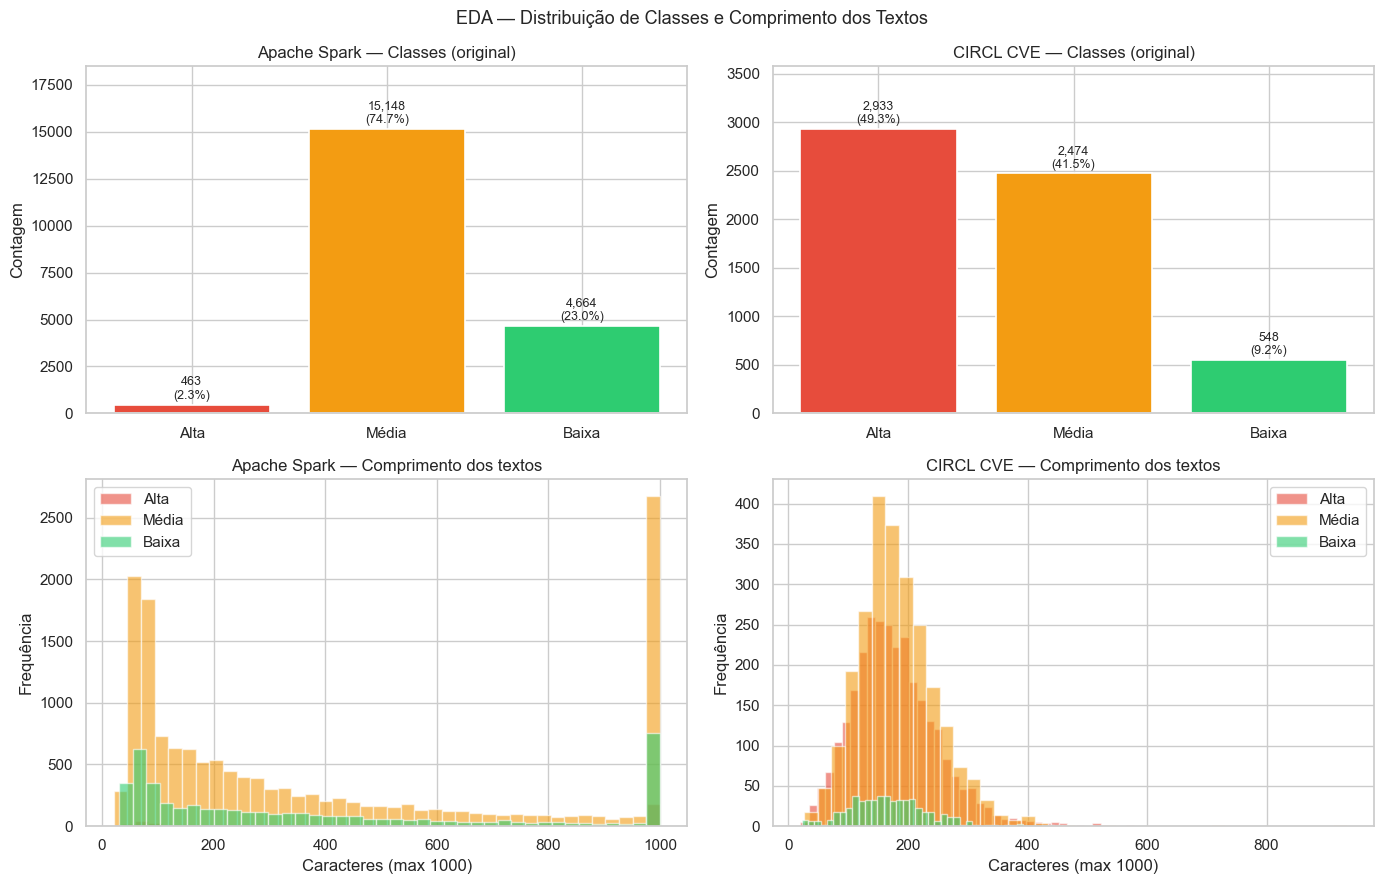


Comprimento dos textos (após limpeza):
  Spark: min=21 | mediana=248 | média=396 | max=1000
  CIRCL: min=20 | mediana=171 | média=179 | max=934


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('EDA — Distribuição de Classes e Comprimento dos Textos', fontsize=13)

for col, (df, nome) in enumerate([(df_spark_full, 'Apache Spark'), (df_circl_full, 'CIRCL CVE')]):
    # Distribuição de classes
    ax = axes[0, col]
    counts = df['label'].value_counts().reindex(CLASSES)
    bars = ax.bar(CLASSES, counts, color=[CORES[c] for c in CLASSES], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{nome} — Classes (original)')
    ax.set_ylabel('Contagem'); ax.set_ylim(0, counts.max() * 1.22)

    # Comprimento dos textos por classe
    ax = axes[1, col]
    for cls in CLASSES:
        lens = df[df['label'] == cls]['text'].str.len().clip(upper=1000)
        ax.hist(lens, bins=40, alpha=0.6, label=cls, color=CORES[cls])
    ax.set_title(f'{nome} — Comprimento dos textos')
    ax.set_xlabel('Caracteres (max 1000)'); ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas descritivas de comprimento
print('\nComprimento dos textos (após limpeza):')
for df, nome in [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]:
    s = df['text'].str.len()
    print(f'  {nome}: min={s.min()} | mediana={s.median():.0f} | média={s.mean():.0f} | max={s.max()}')

---
## Seção 3 — Pré-processamento de Texto

### O que fazemos (e o que não fazemos)

Nosso pré-processamento depende da representação: **mínimo para embeddings** (transformers precisam de texto natural) e **completo para TF-IDF** (stopwords + Porter stemming via `_lamkanfi_tokenizer`, alinhado a Lamkanfi 2010 e Spanos 2018):

| Etapa | Fazemos? | Justificativa |
|---|---|---|
| Lower-case | ✅ | Normaliza maiúsculas sem perda semântica |
| Colapsar espaços | ✅ | Remove ruído de formatação |
| Truncar em 1000 chars | ✅ | Limita custo de embedding sem perder info |
| Remover stopwords | ✅ TF-IDF / ❌ Embeddings | TF-IDF usa `_lamkanfi_tokenizer` (alinhado a Lamkanfi/Spanos); embeddings precisam do contexto |
| Stemming (Porter) | ✅ TF-IDF / ❌ Embeddings | TF-IDF aplica Porter via `_lamkanfi_tokenizer`; embeddings perderiam semântica |
| Remover pontuação | ❌ | Pontuação carrega informação (ex: `NullPointerException`) |

### Diferença em relação a Lamkanfi et al. (2010)

Lamkanfi usa pré-processamento mais completo **antes** da vetorização:

| Etapa | Lamkanfi (2010) | Este projeto |
|---|---|---|
| Tokenização | ✅ apenas chars alfa, lowercase | ✅ lowercase + whitespace |
| Remoção de stopwords | ✅ stopwords inglês padrão | ✅ TF-IDF usa `_lamkanfi_tokenizer`; embeddings usam texto bruto |
| Stemming | ✅ Porter Stemmer | ✅ Porter Stemmer para TF-IDF; embeddings usam texto bruto |
| Representação | BoW (CountVectorizer) | TF-IDF sublinear + Embeddings |
| Classificação | Binária (severo / não-severo) | Tri-classe (Alta / Média / Baixa) |
| Classificador | Naïve Bayes | Ensemble híbrido (Stacking) |

O baseline **NB-Lamkanfi (BoW+Stem)** na Seção 7 reproduz fielmente essa pipeline (CountVectorizer + `_lamkanfi_tokenizer` com stopwords + Porter stemming + ComplementNB). Spanos & Angelis (2018) utilizam **exatamente o mesmo pré-processamento**, portanto o `_lamkanfi_tokenizer` é igualmente válido para comparação com Spanos. **Desde Jun/2026 todos os modelos TF-IDF (NB, LogReg, SVM, DT) também usam esse tokenizador** — apenas os modelos de embeddings recebem texto bruto.

### Análises desta seção

1. **Efeito do truncamento** — quanta informação perdemos ao truncar em 1000 chars?
2. **Tokens mais frequentes por classe** — que palavras distinguem Alta/Média/Baixa?
3. **Bigramas por classe** — pares de palavras mais discriminativos
4. **Top features TF-IDF por classe** — quais termos o TF-IDF valoriza mais?

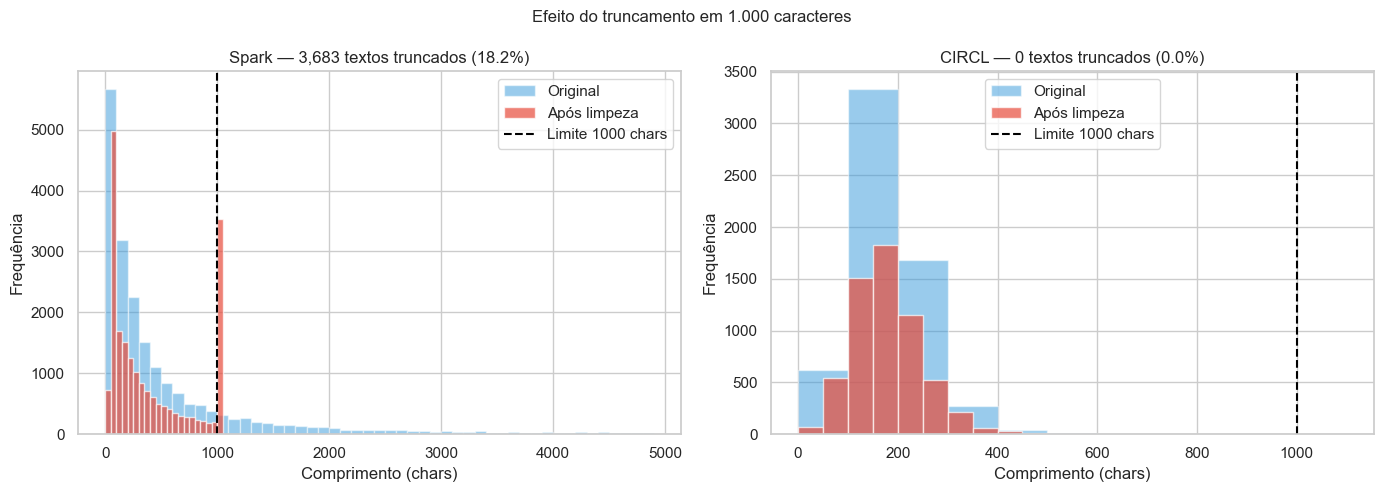


Porcentagem de textos truncados por classe:
  Spark:
    Alta  : 40.6% truncados
    Média : 18.0% truncados
    Baixa : 16.6% truncados
  CIRCL:
    Alta  : 0.0% truncados
    Média : 0.0% truncados
    Baixa : 0.0% truncados


In [4]:
# ── 3.1 Efeito do truncamento em 1000 caracteres ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efeito do truncamento em 1.000 caracteres', fontsize=12)

for ax, (df, nome) in zip(axes, [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]):
    raw_len  = df['text_raw'].str.len()
    clean_len = df['text'].str.len()
    truncados = (raw_len > 1000).sum()
    pct_trunc = truncados / len(df) * 100

    bins = range(0, min(int(raw_len.max()) + 200, 5000), 100)
    ax.hist(raw_len.clip(upper=5000), bins=bins, alpha=0.5, label='Original', color='#3498db')
    ax.hist(clean_len, bins=range(0, 1100, 50), alpha=0.7, label='Após limpeza', color='#e74c3c')
    ax.axvline(1000, color='black', linestyle='--', linewidth=1.5, label='Limite 1000 chars')
    ax.set_title(f'{nome} — {truncados:,} textos truncados ({pct_trunc:.1f}%)')
    ax.set_xlabel('Comprimento (chars)'); ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preproc_truncamento.png', dpi=150, bbox_inches='tight')
plt.show()

# Detalhamento por classe
print('\nPorcentagem de textos truncados por classe:')
for df, nome in [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]:
    print(f'  {nome}:')
    for cls in CLASSES:
        sub = df[df['label'] == cls]
        pct = (sub['text_raw'].str.len() > 1000).mean() * 100
        print(f'    {cls:6s}: {pct:.1f}% truncados')

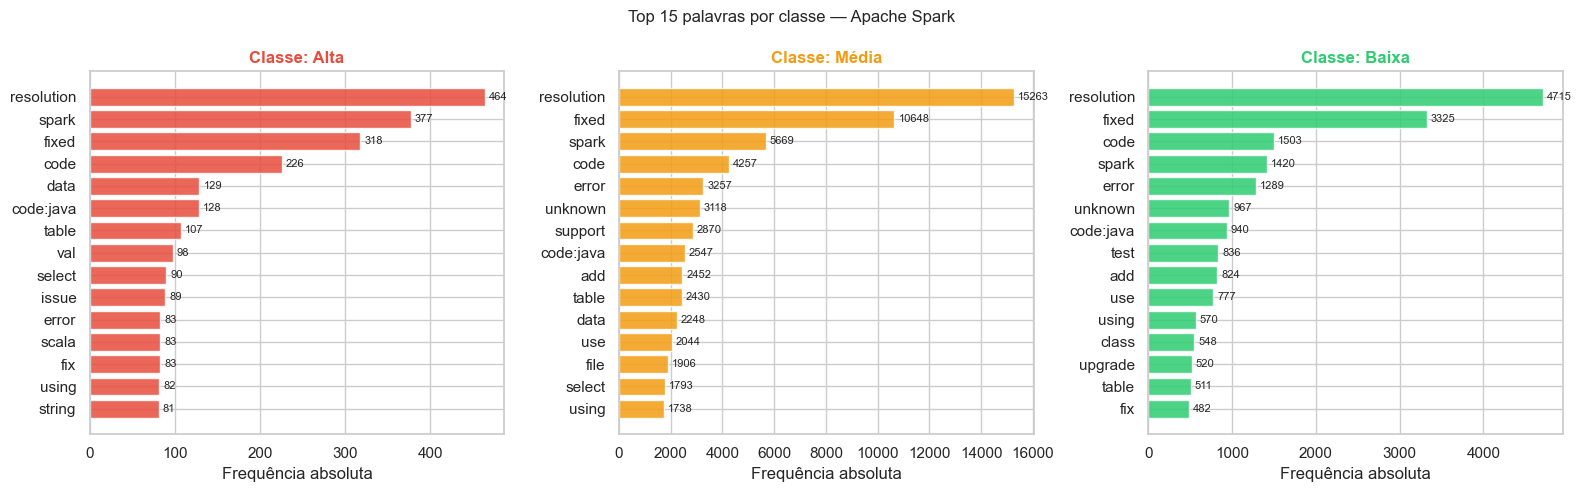

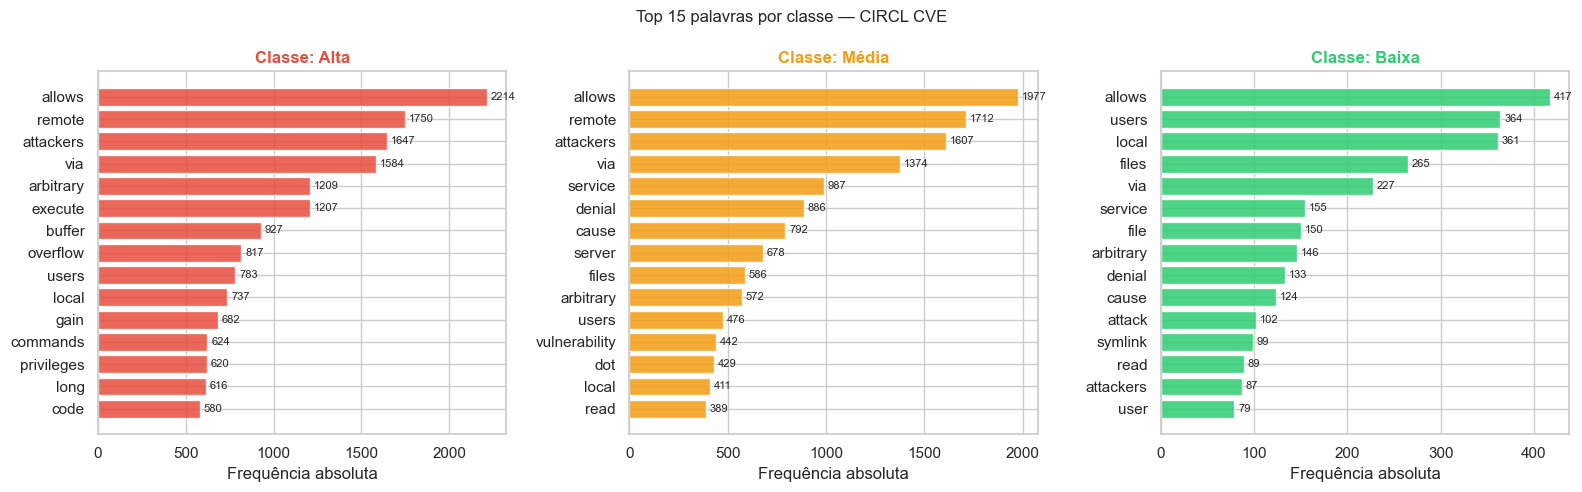

In [5]:
# ── 3.2 Termos mais frequentes por classe ─────────────────────────────────────

def top_tokens(df, classe, n=20, stopwords=STOPWORDS):
    """Retorna os n tokens mais frequentes em textos de uma classe (sem stopwords)."""
    textos = df[df['label'] == classe]['text']
    words  = []
    for t in textos:
        # Tokenização simples: split por espaço + remove pontuação
        for w in t.split():
            w = w.strip(string.punctuation)
            if len(w) > 2 and w not in stopwords:
                words.append(w)
    return Counter(words).most_common(n)


def plot_top_tokens(df, dataset_name, n=15):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Top {n} palavras por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        tokens = top_tokens(df, cls, n=n)
        words, counts = zip(*tokens) if tokens else ([], [])
        bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                       color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Frequência absoluta')
        for bar, val in zip(bars, reversed(counts)):
            ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=8)

    plt.tight_layout()
    fname = f'preproc_tokens_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_top_tokens(df_spark_full, 'Apache Spark')
plot_top_tokens(df_circl_full, 'CIRCL CVE')

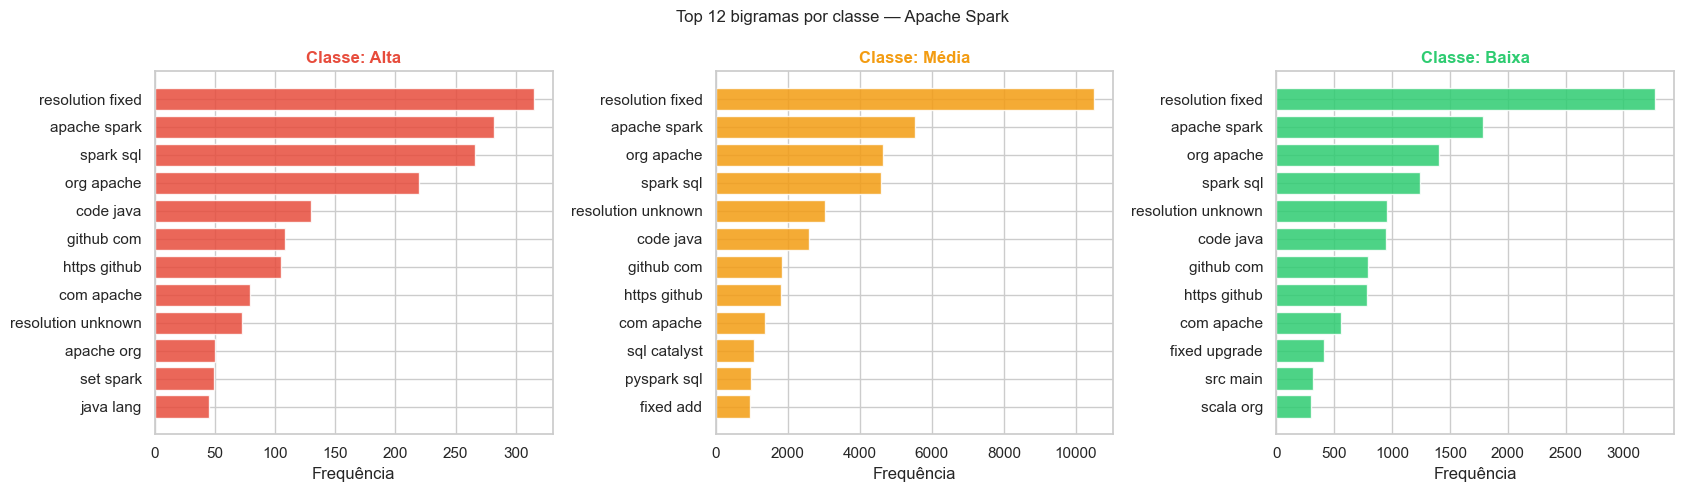

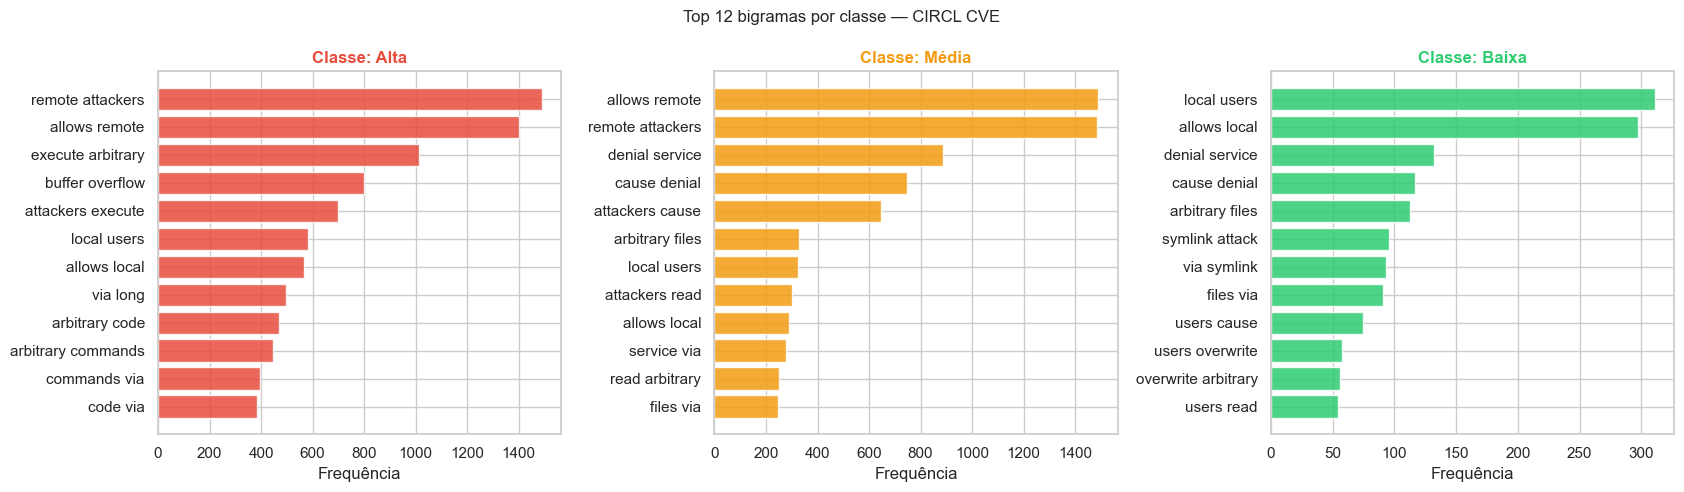

In [6]:
# ── 3.3 Bigramas mais frequentes por classe ───────────────────────────────────

def top_ngrams(df, classe, n=15, ngram_range=(2, 2)):
    """Extrai os n n-gramas mais frequentes para uma classe usando CountVectorizer."""
    textos = df[df['label'] == classe]['text'].tolist()
    vec = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=list(STOPWORDS),
        max_features=500,
        min_df=2,
    )
    try:
        X = vec.fit_transform(textos)
    except ValueError:
        return []
    freqs = np.asarray(X.sum(axis=0)).flatten()
    vocab = {v: k for k, v in vec.vocabulary_.items()}
    top   = sorted(zip(freqs, [vocab[i] for i in range(len(freqs))]), reverse=True)[:n]
    return [(gram, freq) for freq, gram in top]


def plot_ngrams(df, dataset_name, n=12):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Top {n} bigramas por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        grams = top_ngrams(df, cls, n=n)
        if not grams:
            ax.set_title(f'{cls} — sem bigramas'); continue
        words, counts = zip(*grams)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Frequência')

    plt.tight_layout()
    fname = f'preproc_bigrams_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_ngrams(df_spark_full, 'Apache Spark')
plot_ngrams(df_circl_full, 'CIRCL CVE')

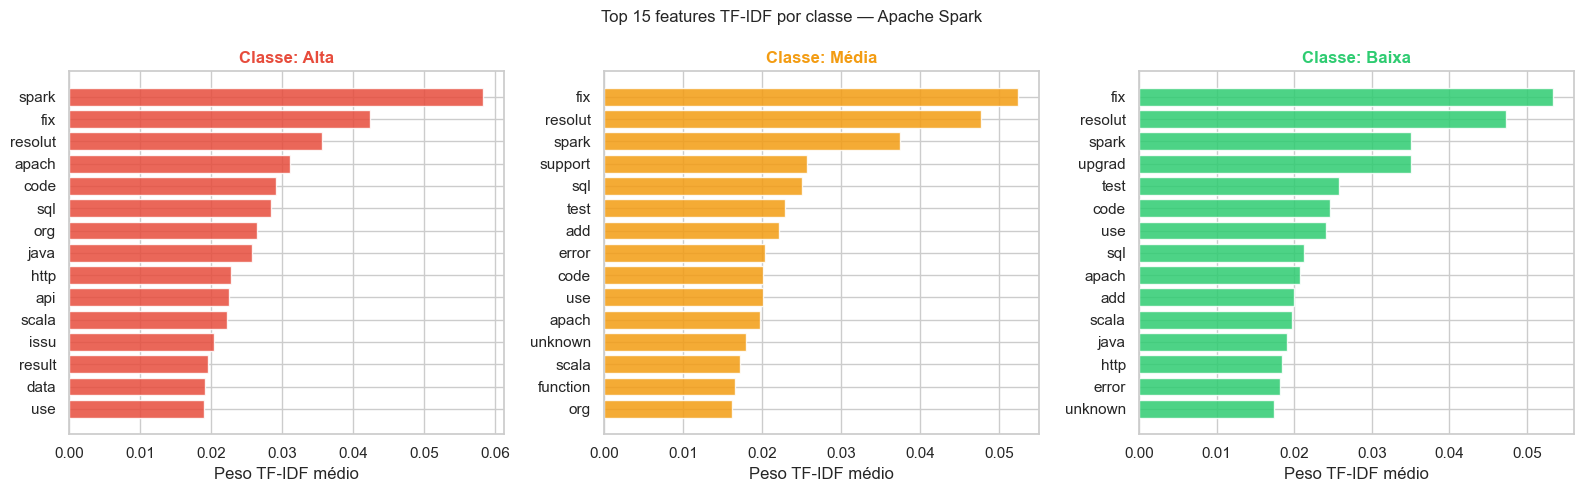

Salvo: resultados/preproc_tfidf_apache_spark.png


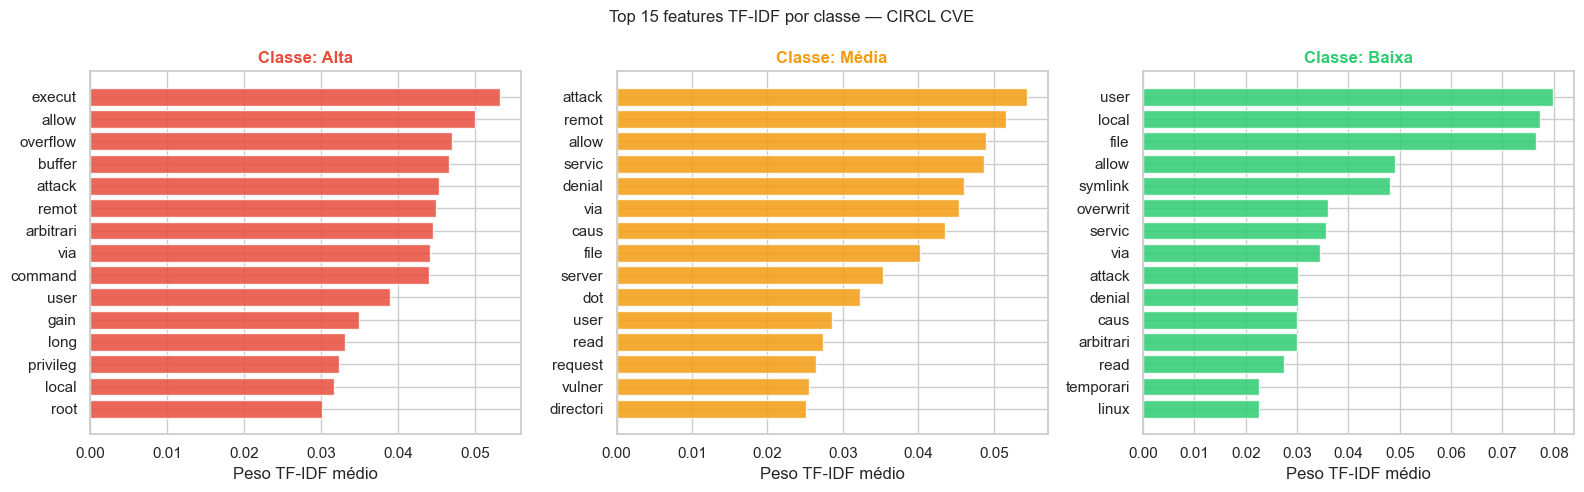

Salvo: resultados/preproc_tfidf_circl_cve.png


In [7]:
# ── 3.4 Top features TF-IDF por classe (média dos pesos) ─────────────────────
#
# Treinamos um TF-IDF em todo o dataset e calculamos o peso médio de cada
# token para cada classe. Isso revela o que o TF-IDF "enxerga" como
# discriminativo por classe — independentemente do classificador.

def plot_tfidf_top_features(df, dataset_name, n=15):
    tfidf = TfidfVectorizer(max_features=10_000, sublinear_tf=True,
                            tokenizer=_lamkanfi_tokenizer)
    X = tfidf.fit_transform(df['text'])
    vocab = np.array(tfidf.get_feature_names_out())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Top {n} features TF-IDF por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        mask       = df['label'].values == cls
        mean_tfidf = np.asarray(X[mask].mean(axis=0)).flatten()
        top_idx    = mean_tfidf.argsort()[::-1][:n]
        top_words  = vocab[top_idx]
        top_vals   = mean_tfidf[top_idx]

        ax.barh(list(reversed(top_words)), list(reversed(top_vals)),
                color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Peso TF-IDF médio')

    plt.tight_layout()
    fname = f'preproc_tfidf_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: resultados/{fname}')


plot_tfidf_top_features(df_spark_full, 'Apache Spark')
plot_tfidf_top_features(df_circl_full, 'CIRCL CVE')

In [8]:
# ── 3.5 Exemplos reais de textos por classe ───────────────────────────────────
#
# Verificação qualitativa: os rótulos fazem sentido? O texto é informativo?

print('=== Exemplos de texto por classe — Apache Spark ===\n')
for cls in CLASSES:
    amostras = df_spark_full[df_spark_full['label'] == cls]['text'].sample(2, random_state=SEED)
    print(f'--- {cls} ---')
    for i, txt in enumerate(amostras, 1):
        print(f'  [{i}] {txt[:300]}...')
    print()

print('=== Exemplos de texto por classe — CIRCL CVE ===\n')
for cls in CLASSES:
    amostras = df_circl_full[df_circl_full['label'] == cls]['text'].sample(2, random_state=SEED)
    print(f'--- {cls} ---')
    for i, txt in enumerate(amostras, 1):
        print(f'  [{i}] {txt[:300]}...')
    print()

=== Exemplos de texto por classe — Apache Spark ===

--- Alta ---
  [1] resolution: fixed | star expansion after outer join asymmetrically includes joining key when star expansion is used on left side of a join, the result will include joining key, while on the right side of join it doesn't. i would expect the behaviour to be symmetric (either include on both sides or o...
  [2] resolution: fixed | array_insert should fail with 0 index...

--- Média ---
  [1] resolution: unknown | support drop multi-level partition v2 table with partial partition spec...
  [2] resolution: fixed | correct csv schema inference and data parsing behavior on columns with mixed dates and timestamps in this ticket https://issues.apache.org/jira/browse/spark-39469, we introduced the support of date type in csv schema inference. the schema inference behavior on date time columns n...

--- Baixa ---
  [1] resolution: fixed | images used in pyspark documentation still use koalas images in [transform and apply a f

---
## Seção 4 — Balanceamento de Classes

### Estratégia: Real-First + SMOTE dentro do fold

**Etapa 1 — Undersampling real-first** (`make_balanced_sample`):
- Classes com **mais** de `N_PER_CLASS` amostras → subamostradas para `N_PER_CLASS`
- Classes com **menos** de `N_PER_CLASS` amostras → mantidas inteiras

**Etapa 2 — SMOTE dentro do fold** (via `ImbPipeline`):
- Em cada fold, SMOTE gera amostras sintéticas **só no treino**
- O fold de **teste** nunca vê amostras sintéticas → sem data leakage

> **SMOTE:** Para dois vizinhos $x_i$ e $x_{nn}$, gera $x_{new} = x_i + \lambda(x_{nn} - x_i)$, $\lambda \sim U(0,1)$

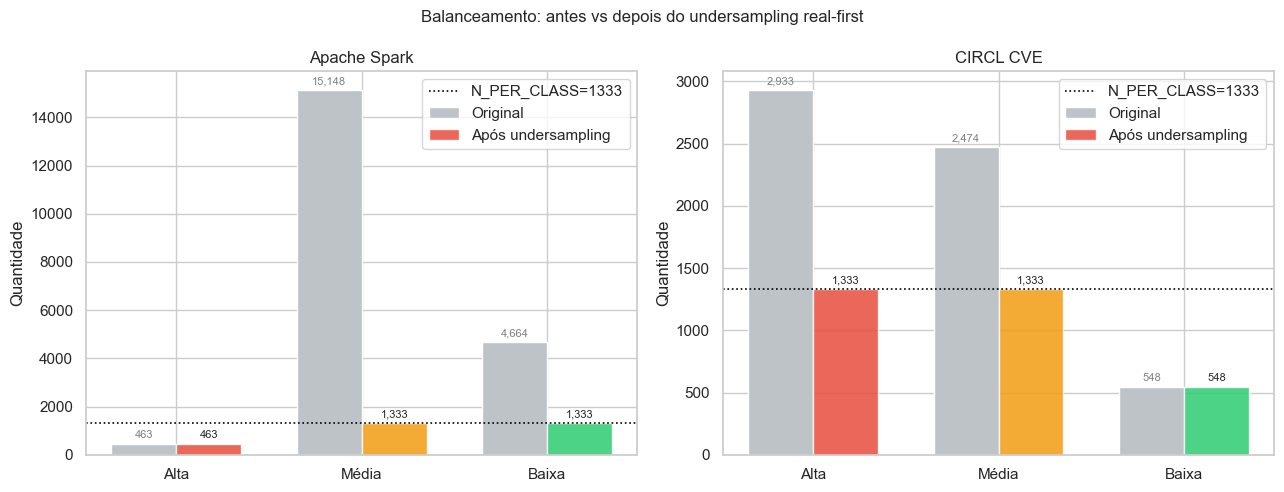

Após undersampling:
  Spark: 3129 amostras total
    Alta  : 463 (14.8%)
    Média : 1,333 (42.6%)
    Baixa : 1,333 (42.6%)
  CIRCL: 3214 amostras total
    Alta  : 1,333 (41.5%)
    Média : 1,333 (41.5%)
    Baixa : 548 (17.1%)


In [9]:
def make_balanced_sample(df, n_per_class=N_PER_CLASS, label_col='label', random_state=SEED):
    """Undersampling das classes maioritárias para n_per_class; minoritárias ficam intactas."""
    groups = []
    for label, group in df.groupby(label_col):
        n = min(len(group), n_per_class)
        groups.append(resample(group, replace=False, n_samples=n, random_state=random_state))
    return pd.concat(groups).sample(frac=1, random_state=random_state).reset_index(drop=True)


df_spark = make_balanced_sample(df_spark_full)
df_circl = make_balanced_sample(df_circl_full)

# ── Visualização: antes vs depois do undersampling ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Balanceamento: antes vs depois do undersampling real-first', fontsize=12)

for ax, (df_orig, df_bal, nome) in zip(axes, [
    (df_spark_full, df_spark, 'Apache Spark'),
    (df_circl_full, df_circl, 'CIRCL CVE'),
]):
    x = np.arange(len(CLASSES))
    w = 0.35
    antes  = [df_orig['label'].value_counts().reindex(CLASSES)[c] for c in CLASSES]
    depois = [df_bal['label'].value_counts().reindex(CLASSES)[c]  for c in CLASSES]

    b1 = ax.bar(x - w/2, antes,  w, label='Original', color='#bdc3c7', edgecolor='white')
    b2 = ax.bar(x + w/2, depois, w, label='Após undersampling', color=[CORES[c] for c in CLASSES],
                edgecolor='white', alpha=0.85)

    for bar, val in zip(b1, antes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(antes)*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=8, color='gray')
    for bar, val in zip(b2, depois):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(antes)*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(CLASSES)
    ax.set_title(nome); ax.set_ylabel('Quantidade')
    ax.legend()

    # Linha de N_PER_CLASS
    ax.axhline(N_PER_CLASS, color='black', linestyle=':', linewidth=1.2,
               label=f'N_PER_CLASS={N_PER_CLASS}')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'balanceamento_antes_depois.png', dpi=150, bbox_inches='tight')
plt.show()

print('Após undersampling:')
for df, nome in [(df_spark, 'Spark'), (df_circl, 'CIRCL')]:
    print(f'  {nome}: {len(df)} amostras total')
    for cls in CLASSES:
        n = (df['label'] == cls).sum()
        print(f'    {cls:6s}: {n:,} ({n/len(df)*100:.1f}%)')

---
## Seção 5 — Representação Textual: Embeddings Qwen3

O **Qwen3-Embedding-0.6B** transforma cada texto em um vetor denso de 1024 dimensões.
Textos semanticamente similares ficam próximos no espaço vetorial.

Os embeddings são **pré-calculados** (modelo congelado) e armazenados em cache `.npy`.

> **Primeira execução:** download ~600 MB + inferência ~17 min em CPU.  
> **Execuções seguintes:** carrega do cache em segundos.

In [10]:
def embed_texts(texts, cache_name, model_name=EMBED_MODEL, batch_size=64,
                ollama_url='http://localhost:11434'):
    """Gera embeddings via Ollama API com cache em disco."""
    import requests
    model_tag  = model_name.replace(':', '_').replace('/', '_')
    cache_path = DATA_DIR / f'emb_{cache_name}_{model_tag}.npy'
    if cache_path.exists():
        emb = np.load(str(cache_path))
        print(f'Cache: {cache_path} → shape {emb.shape}')
        return emb
    print(f'Gerando embeddings com {model_name} via Ollama ({len(texts)} textos)...')
    all_emb = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Batches'):
        batch = texts[i:i + batch_size]
        r = requests.post(
            f'{ollama_url}/api/embed',
            json={'model': model_name, 'input': batch},
            timeout=120,
        )
        r.raise_for_status()
        all_emb.extend(r.json()['embeddings'])
    emb = np.array(all_emb, dtype=np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.maximum(norms, 1e-12)
    np.save(str(cache_path), emb)
    print(f'Salvo: {cache_path} | shape {emb.shape}')
    return emb


print('Gerando embeddings para Spark...')
emb_spark = embed_texts(df_spark['text'].tolist(), cache_name='spark_balanced')

print('\nGerando embeddings para CIRCL...')
emb_circl = embed_texts(df_circl['text'].tolist(), cache_name='circl_balanced')

print(f'\nSpark: {emb_spark.shape} | CIRCL: {emb_circl.shape}')

Gerando embeddings para Spark...
Cache: ..\data\emb_spark_balanced_qwen3-embedding_0.6b.npy → shape (3129, 1024)

Gerando embeddings para CIRCL...
Cache: ..\data\emb_circl_balanced_qwen3-embedding_0.6b.npy → shape (3214, 1024)

Spark: (3129, 1024) | CIRCL: (3214, 1024)


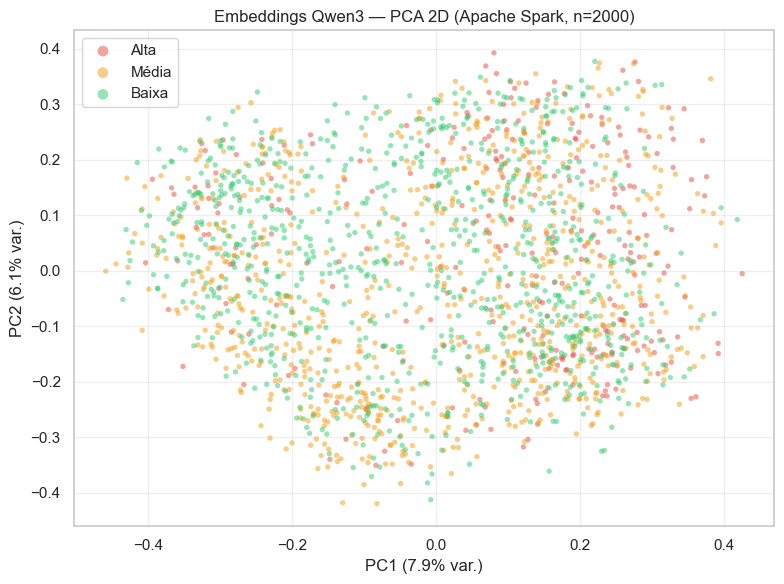

Variância explicada pelos 2 PCs: 14.0%


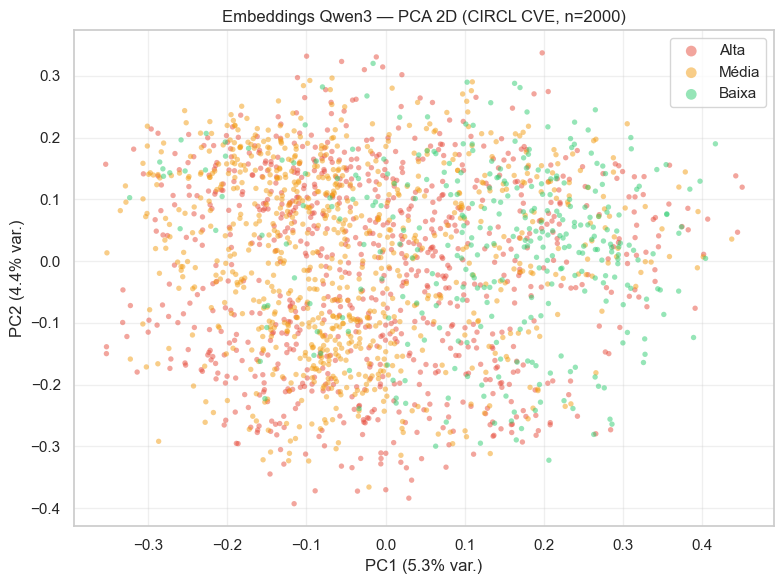

Variância explicada pelos 2 PCs: 9.7%


In [11]:
# ── Visualização dos embeddings com PCA (projeção 2D) ─────────────────────────
#
# PCA reduz 1024 → 2 dimensões para inspecionar visualmente a separabilidade
# das classes no espaço de embeddings. Clusters bem separados sugerem que
# os embeddings capturam informação discriminativa.

from sklearn.decomposition import PCA

def plot_embeddings_pca(emb, y, dataset_name):
    pca = PCA(n_components=2, random_state=SEED)
    # Subsample para agilidade (máx 2000 pontos)
    n = min(len(emb), 2000)
    idx = np.random.choice(len(emb), n, replace=False)
    emb_2d = pca.fit_transform(emb[idx])
    y_sub  = np.array(y)[idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in CLASSES:
        mask = y_sub == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=CORES[cls], label=cls, alpha=0.5, s=15, edgecolors='none')
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var.)')
    ax.set_title(f'Embeddings Qwen3 — PCA 2D ({dataset_name}, n={n})')
    ax.legend(markerscale=2); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f'embeddings_pca_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Variância explicada pelos 2 PCs: {(var.sum()*100):.1f}%')


plot_embeddings_pca(emb_spark, df_spark['label'].values, 'Apache Spark')
plot_embeddings_pca(emb_circl, df_circl['label'].values, 'CIRCL CVE')

---
## Seção 6 — Framework de Avaliação

### Métricas utilizadas

| Métrica | Fórmula | Por que usar |
|---|---|---|
| **F1-macro** | Média do F1 por classe | Métrica principal; peso igual entre classes |
| **Acurácia** | Acertos / Total | Intuicível, mas enganosa com desbalanceamento |
| **Precisão-macro** | Média da precisão por classe | Custo de falsos positivos |
| **Recall-macro** | Média do recall por classe | Custo de falsos negativos (crítico para Alta) |
| **MCC** | Correlação Matthews | Robusto ao desbalanceamento; [-1, 1] |
| **Kappa** | Acordo além do acaso | 0=aleatório, 1=perfeito |
| **F1 por classe** | F1 de Alta, Média, Baixa | O modelo aprende a classe rara? |

In [12]:
def compute_metrics(y_true, y_pred, classes=CLASSES):
    """Calcula F1-macro, Acurácia, Precisão, Recall, MCC, Kappa e F1 por classe."""
    f1_per = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    m = {
        'F1-macro':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Acurácia':  accuracy_score(y_true, y_pred),
        'Precisão':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC':       matthews_corrcoef(y_true, y_pred),
        'Kappa':     cohen_kappa_score(y_true, y_pred),
    }
    for cls, f1 in zip(classes, f1_per):
        m[f'F1-{cls}'] = f1
    return m


def safe_k(y, default=3):
    min_count = pd.Series(y).value_counts().min()
    return max(1, min(default, min_count - 1))


def index_X(X, idx):
    if isinstance(X, np.ndarray) or hasattr(X, 'tocsr'):
        return X[idx]
    return [X[i] for i in idx]


def evaluate_pipeline(pipeline, X, y, n_splits=N_OUTER, seed=SEED):
    """Validação cruzada estratificada com SMOTE apenas no fold de treino."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y  = np.array(y)
    records, y_true_all, y_pred_all = [], [], []

    for tr_idx, te_idx in cv.split(X, y):
        X_tr, X_te = index_X(X, tr_idx), index_X(X, te_idx)
        y_tr, y_te = y[tr_idx], y[te_idx]
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)
        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        records.append(compute_metrics(y_te, y_pred))

    folds_df = pd.DataFrame(records)
    return {
        'folds':   folds_df,
        'summary': folds_df.agg(['mean', 'std']),
        'y_true':  np.array(y_true_all),
        'y_pred':  np.array(y_pred_all),
    }


def print_summary(result, nome):
    m = result['summary']
    print(f'\n── {nome} ──')
    for col in ['F1-macro','Acurácia','Precisão','Recall','MCC','Kappa'] + [f'F1-{c}' for c in CLASSES]:
        print(f'  {col:12s}: {m.loc["mean",col]:.4f} ± {m.loc["std",col]:.4f}')

print('Framework definido.')

Framework definido.


---
## Seção 6.5 — Split de Tuning vs. Avaliação (anti-leakage)

A busca de hiperparâmetros (Seção 6.6) e a avaliação final (baselines, Stacking,
Voto Ponderado) **não podem usar exatamente o mesmo conjunto de dados completo**.

**Por quê?** Se o `GridSearchCV` escolhe os "melhores" hiperparâmetros olhando para
100% dos dados balanceados, e depois a avaliação final faz outra validação cruzada
sobre esses mesmos 100%, qualquer linha que caia no fold de teste da avaliação final
quase certamente esteve no treino durante a busca de hiperparâmetros. A *escolha* da
configuração já "viu" parte do que depois é tratado como teste — um viés otimista
bem documentado por **Cawley & Talbot (2010, JMLR)**, distinto (e adicional) ao
anti-leakage de SMOTE/TF-IDF já garantido dentro de cada fold individual.

A alternativa rigorosa — *nested CV* (refazer o grid search dentro de cada um dos
`N_OUTER` folds externos) — multiplicaria o tempo de execução em ~10x. Em vez disso,
isolamos uma fração `TUNE_FRAC` dos dados balanceados **exclusivamente** para a busca
de hiperparâmetros; o restante (`*_eval`) nunca é visto durante o tuning e é o único
conjunto usado em baselines, Stacking e Voto Ponderado.


In [13]:
from sklearn.model_selection import train_test_split

TUNE_FRAC = 0.2  # fração reservada exclusivamente para a busca de hiperparâmetros


def split_tune_eval(df, emb, tune_frac=TUNE_FRAC, seed=SEED):
    """Separa (df, emb) em um subconjunto de tuning e um de avaliação, estratificado por classe.

    O subconjunto de tuning alimenta apenas busca_hiperparametros(); o de avaliação
    alimenta run_baselines/evaluate_stacking/run_weighted_voting — sem overlap entre os dois.
    """
    idx = np.arange(len(df))
    idx_tune, idx_eval = train_test_split(
        idx, train_size=tune_frac, stratify=df['label'].values, random_state=seed)
    df_tune = df.iloc[idx_tune].reset_index(drop=True)
    df_eval = df.iloc[idx_eval].reset_index(drop=True)
    return df_tune, emb[idx_tune], df_eval, emb[idx_eval]


df_spark_tune, emb_spark_tune, df_spark_eval, emb_spark_eval = split_tune_eval(df_spark, emb_spark)
df_circl_tune, emb_circl_tune, df_circl_eval, emb_circl_eval = split_tune_eval(df_circl, emb_circl)

print('Split tuning vs. avaliação (sem overlap):')
for nome, df_t, df_e in [('Spark', df_spark_tune, df_spark_eval),
                         ('CIRCL', df_circl_tune, df_circl_eval)]:
    print(f'  {nome}: tuning={len(df_t)} amostras | avaliação={len(df_e)} amostras')
    for cls in CLASSES:
        nt = (df_t['label'] == cls).sum(); ne = (df_e['label'] == cls).sum()
        print(f'    {cls:6s}: tuning={nt:4d} | avaliação={ne:4d}')


Split tuning vs. avaliação (sem overlap):
  Spark: tuning=625 amostras | avaliação=2504 amostras
    Alta  : tuning=  93 | avaliação= 370
    Média : tuning= 266 | avaliação=1067
    Baixa : tuning= 266 | avaliação=1067
  CIRCL: tuning=642 amostras | avaliação=2572 amostras
    Alta  : tuning= 266 | avaliação=1067
    Média : tuning= 266 | avaliação=1067
    Baixa : tuning= 110 | avaliação= 438


---
## Seção 6.6 — Ajuste de Hiperparâmetros (GridSearchCV)

Antes de avaliar os baselines com validação cruzada completa, buscamos os melhores
hiperparâmetros via **GridSearchCV exaustivo** (5 folds internos) para os **13 modelos**,
usando apenas o subconjunto de *tuning* isolado na Seção 6.5 (`df_*_tune`/`emb_*_tune`).

### Por que fazer isso antes dos baselines?

- Treinar baselines com hiperparâmetros padrão (default) é um **piso**, não um teto
- Hiperparâmetros otimizados garantem que a comparação entre modelos e o stacking
  seja justa — estamos comparando cada modelo no seu melhor, não com configs arbitrárias
- O SMOTE é aplicado **dentro de cada fold** do search → sem leakage dentro do tuning
- O conjunto de tuning é isolado do conjunto de avaliação (Seção 6.5) → sem leakage
  entre a escolha de hiperparâmetros e a validação cruzada final

### O que é buscado

Os modelos com hiperparâmetros próprios (NB, LogReg, SVM, Decision Tree, RF, KNN, XGBoost, LightGBM,
CatBoost, MLP, ELM) têm grids de busca. **NB-Lamkanfi (MultinomialNB)** tem grid de alpha **próprio** sobre a representação BoW (`nb_lam_alpha`); **NB-Complement (BoW+Stem)** reusa o mesmo `nb_lam_alpha` (mesma representação, isola só o classificador). Total: **13 modelos**.

In [14]:
class ELMClassifier(BaseEstimator, ClassifierMixin):
    """Extreme Learning Machine (ELM) para classificação.
    Pesos de entrada aleatórios fixos; pesos de saída via pseudo-inversa.
    """
    def __init__(self, hidden_neurons=500, random_state=SEED):
        self.hidden_neurons = hidden_neurons
        self.random_state   = random_state

    @staticmethod
    def _sigmoid(X):
        return 1.0 / (1.0 + np.exp(-np.clip(X, -500, 500)))

    def fit(self, X, y):
        X   = np.asarray(X, dtype=float)
        rng = np.random.RandomState(self.random_state)
        self._le      = LabelEncoder().fit(y)
        y_enc         = self._le.transform(y)
        n_cls         = len(self._le.classes_)
        Y             = np.eye(n_cls)[y_enc]
        self._W_in    = rng.randn(X.shape[1], self.hidden_neurons)
        self._b       = rng.randn(self.hidden_neurons)
        H             = self._sigmoid(X @ self._W_in + self._b)
        self._W_out   = np.linalg.pinv(H) @ Y
        self.classes_ = self._le.classes_
        return self

    def predict_proba(self, X):
        X   = np.asarray(X, dtype=float)
        H   = self._sigmoid(X @ self._W_in + self._b)
        out = H @ self._W_out
        e   = np.exp(out - out.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self._le.inverse_transform(self.predict_proba(X).argmax(axis=1))


class XGBStringWrapper(BaseEstimator, ClassifierMixin):
    """XGBoost com LabelEncoder interno para aceitar rótulos em string."""
    def __init__(self, n_estimators=200, learning_rate=0.1, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, random_state=SEED):
        self.n_estimators = n_estimators; self.learning_rate = learning_rate
        self.max_depth = max_depth; self.subsample = subsample
        self.colsample_bytree = colsample_bytree; self.random_state = random_state

    def fit(self, X, y):
        self._le = LabelEncoder()
        y_enc = self._le.fit_transform(y)
        self._clf = XGBClassifier(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, eval_metric='mlogloss',
            random_state=self.random_state, verbosity=0,
            **XGB_GPU,
        )
        self._clf.fit(X, y_enc)
        self.classes_ = self._le.classes_
        return self

    def predict(self, X):
        return self._le.inverse_transform(self._clf.predict(X))

    def predict_proba(self, X):
        return self._clf.predict_proba(X)



from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

SEARCH_FOLDS  = 5

_search_cv = StratifiedKFold(n_splits=SEARCH_FOLDS, shuffle=True, random_state=SEED)


def busca_hiperparametros(df, emb, dataset_name):
    """GridSearchCV (5 folds) para todos os baselines com hiperparâmetros ajustáveis.

    SMOTE é aplicado dentro de cada fold do search para evitar data leakage.
    Retorna dict com os melhores hiperparâmetros — usado por build_baselines() e
    evaluate_stacking() para substituir os defaults.
    """
    texts = df['text'].tolist()
    y     = df['label'].values
    bp    = {}

    print(f'\n=== Busca de Hiperparâmetros — {dataset_name} (GridSearchCV × {SEARCH_FOLDS} folds) ===')

    # ── NB + TF-IDF ───────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   ComplementNB()),
    ])
    gs = GridSearchCV(
        pipe, {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(texts, y)
    bp['nb_alpha'] = float(gs.best_params_['clf__alpha'])
    print(f'  NB        alpha={bp["nb_alpha"]:.3f}        → F1-macro={gs.best_score_:.4f}')

    # ── NB-Lamkanfi: BoW + Porter stemming + MultinomialNB (fiel a Lamkanfi 2010) ──
    # Alpha tunado na PRÓPRIA representação BoW (contagem bruta), não no TF-IDF,
    # pois a escala de features difere. O mesmo alpha é reusado pela variante
    # ComplementNB (investigação Multinomial vs Complement na mesma representação).
    pipe = ImbPipeline([
        ('bow',   CountVectorizer(tokenizer=_lamkanfi_tokenizer, max_features=20_000)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   MultinomialNB()),
    ])
    gs = GridSearchCV(
        pipe, {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(texts, y)
    bp['nb_lam_alpha'] = float(gs.best_params_['clf__alpha'])
    print(f'  NB-Lam    alpha={bp["nb_lam_alpha"]:.3f}        → F1-macro={gs.best_score_:.4f}')

    # ── LogReg + TF-IDF ───────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    gs = GridSearchCV(
        pipe, {'clf__C': np.logspace(-2, 2, 15)},
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(texts, y)
    bp['logreg_C'] = float(gs.best_params_['clf__C'])
    print(f'  LogReg    C={bp["logreg_C"]:.5f}          → F1-macro={gs.best_score_:.4f}')

    # ── SVM + TF-IDF ──────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=SEED), cv=3)),
    ])
    gs = GridSearchCV(
        pipe, {'clf__estimator__C': [0.01, 0.1, 1, 10, 100]},
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(texts, y)
    bp['svm_C'] = float(gs.best_params_['clf__estimator__C'])
    print(f'  SVM       C={bp["svm_C"]:.5f}          → F1-macro={gs.best_score_:.4f}')

    # ── Decision Tree + TF-IDF ────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   DecisionTreeClassifier(random_state=SEED)),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__max_depth':         [5, 10, 20, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__criterion':         ['gini', 'entropy'],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(texts, y)
    bp['dt_depth']  = gs.best_params_['clf__max_depth']
    bp['dt_split']  = int(gs.best_params_['clf__min_samples_split'])
    bp['dt_crit']   = gs.best_params_['clf__criterion']
    print(f'  DecTree   depth={bp["dt_depth"]} split={bp["dt_split"]} crit={bp["dt_crit"]}  → F1-macro={gs.best_score_:.4f}')

    # ── RF + Emb ──────────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__max_depth':    [None, 10, 20],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(emb, y)
    bp['rf_n']     = int(gs.best_params_['clf__n_estimators'])
    bp['rf_depth'] = gs.best_params_['clf__max_depth']
    print(f'  RF        n={bp["rf_n"]:3d} depth={bp["rf_depth"]}        → F1-macro={gs.best_score_:.4f}')

    # ── KNN + Emb ─────────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=200, random_state=SEED)),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    KNeighborsClassifier()),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__n_neighbors': [3, 5, 7, 9, 15],
            'clf__weights':     ['uniform', 'distance'],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(emb, y)
    bp['knn_n']       = int(gs.best_params_['clf__n_neighbors'])
    bp['knn_weights'] = gs.best_params_['clf__weights']
    print(f'  KNN       n={bp["knn_n"]:2d} weights={bp["knn_weights"]}       → F1-macro={gs.best_score_:.4f}')

    # ── XGBoost + Emb ─────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    XGBStringWrapper()),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__n_estimators':  [100, 200, 300],
            'clf__max_depth':     [3, 5, 7],
            'clf__learning_rate': [0.03, 0.1, 0.3],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=1, verbose=0,
    )
    gs.fit(emb, y)
    bp['xgb_n']  = int(gs.best_params_['clf__n_estimators'])
    bp['xgb_d']  = int(gs.best_params_['clf__max_depth'])
    bp['xgb_lr'] = float(gs.best_params_['clf__learning_rate'])
    print(f'  XGBoost   n={bp["xgb_n"]:3d} d={bp["xgb_d"]} lr={bp["xgb_lr"]:.5f}  → F1-macro={gs.best_score_:.4f}')

    # ── LightGBM + Emb ────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    LGBMClassifier(random_state=SEED, verbose=-1, **LGBM_GPU)),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__n_estimators':  [100, 200, 300],
            'clf__num_leaves':    [20, 31, 40],
            'clf__learning_rate': [0.03, 0.1, 0.3],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=1, verbose=0,
    )
    gs.fit(emb, y)
    bp['lgbm_n']      = int(gs.best_params_['clf__n_estimators'])
    bp['lgbm_leaves'] = int(gs.best_params_['clf__num_leaves'])
    bp['lgbm_lr']     = float(gs.best_params_['clf__learning_rate'])
    print(f'  LightGBM  n={bp["lgbm_n"]:3d} leaves={bp["lgbm_leaves"]:2d} lr={bp["lgbm_lr"]:.5f}  → F1-macro={gs.best_score_:.4f}')

    # ── CatBoost + Emb ────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    CatBoostClassifier(random_state=SEED, verbose=False, **CATBOOST_GPU)),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__depth':         [4, 6, 8],
            'clf__learning_rate': [0.03, 0.1, 0.3],
            'clf__iterations':    [100, 200, 300],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=1, verbose=0,
    )
    gs.fit(emb, y)
    bp['catboost_depth'] = int(gs.best_params_['clf__depth'])
    bp['catboost_lr']    = float(gs.best_params_['clf__learning_rate'])
    bp['catboost_iter']  = int(gs.best_params_['clf__iterations'])
    print(f'  CatBoost  depth={bp["catboost_depth"]} lr={bp["catboost_lr"]:.5f} iter={bp["catboost_iter"]:3d}  → F1-macro={gs.best_score_:.4f}')

    # ── MLP + Emb ─────────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    MLPClassifier(max_iter=300, random_state=SEED)),
    ])
    gs = GridSearchCV(
        pipe,
        {
            'clf__hidden_layer_sizes': [(64,), (128,), (128, 64)],
            'clf__alpha':              [1e-4, 1e-3, 1e-2],
        },
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(emb, y)
    bp['mlp_hidden'] = gs.best_params_['clf__hidden_layer_sizes']
    bp['mlp_alpha']  = float(gs.best_params_['clf__alpha'])
    print(f'  MLP       hidden={bp["mlp_hidden"]} alpha={bp["mlp_alpha"]:.5f}  → F1-macro={gs.best_score_:.4f}')

    # ── ELM + Emb ─────────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    ELMClassifier(random_state=SEED)),
    ])
    gs = GridSearchCV(
        pipe,
        {'clf__hidden_neurons': [200, 500, 1000]},
        scoring='f1_macro', cv=_search_cv, n_jobs=-1, verbose=0,
    )
    gs.fit(emb, y)
    bp['elm_hidden'] = int(gs.best_params_['clf__hidden_neurons'])
    print(f'  ELM       hidden={bp["elm_hidden"]:4d}             -> F1-macro={gs.best_score_:.4f}')

    return bp


bp_spark = busca_hiperparametros(df_spark_tune, emb_spark_tune, 'Apache Spark')
bp_circl = busca_hiperparametros(df_circl_tune, emb_circl_tune, 'CIRCL CVE')


=== Busca de Hiperparâmetros — Apache Spark (GridSearchCV × 5 folds) ===
  NB        alpha=0.100        → F1-macro=0.4332
  NB-Lam    alpha=2.000        → F1-macro=0.4096
  LogReg    C=1.93070          → F1-macro=0.4902
  SVM       C=0.01000          → F1-macro=0.4653
  DecTree   depth=None split=10 crit=gini  → F1-macro=0.3820
  RF        n=300 depth=None        → F1-macro=0.4711
  KNN       n= 3 weights=distance       → F1-macro=0.3014
  XGBoost   n=200 d=3 lr=0.10000  → F1-macro=0.4810
  LightGBM  n=200 leaves=20 lr=0.10000  → F1-macro=0.4671
  CatBoost  depth=8 lr=0.30000 iter=200  → F1-macro=0.4799
  MLP       hidden=(128,) alpha=0.01000  → F1-macro=0.4452
  ELM       hidden=1000             -> F1-macro=0.3827

=== Busca de Hiperparâmetros — CIRCL CVE (GridSearchCV × 5 folds) ===
  NB        alpha=2.000        → F1-macro=0.6282
  NB-Lam    alpha=5.000        → F1-macro=0.6732
  LogReg    C=0.13895          → F1-macro=0.6877
  SVM       C=0.10000          → F1-macro=0.6803
  DecTr

---
## Seção 7 — Classificadores Base (Baselines)

| # | Modelo | Representação | Biblioteca | Justificativa |
|---|---|---|---|---|
| 1 | Complement Naive Bayes | TF-IDF | sklearn | Baseline Lamkanfi; robusto ao desbalanceamento |
| 2 | Regressão Logística | TF-IDF | sklearn | Linear, interpretável |
| 3 | SVM Linear (calibrado) | TF-IDF | sklearn | Margem máxima em alta dimensão |
| 4 | Decision Tree | TF-IDF | sklearn | Árvore interpretável; referência simples |
| 5 | Random Forest | Embeddings | sklearn | Ensemble de árvores, não-linear |
| 6 | KNN | Embeddings | sklearn | Baseline por similaridade no espaço semântico |
| 7 | **XGBoost** | Embeddings | **xgboost** | Gradient boosting (não-sklearn) |
| 8 | **LightGBM** | Embeddings | **lightgbm** | Boosting leaf-wise (não-sklearn) |
| 9 | **CatBoost** | Embeddings | **catboost** | Boosting com suporte nativo a categorias |
| 10 | MLP | Embeddings | sklearn | Rede neural multicamadas como referência |
| 11 | **ELM** | Embeddings | numpy | Extreme Learning Machine — pesos de saída por MQ |
| 12 | **NB-Lamkanfi (BoW+Stem)** | BoW + Stemming Porter | sklearn + nltk | Reprodução **fiel** de Lamkanfi (2010): CountVectorizer + stopwords + Porter stemmer + **MultinomialNB** |
| 13 | **NB-Complement (BoW+Stem)** | BoW + Stemming Porter | sklearn + nltk | Investigação: mesma entrada BoW, **ComplementNB** (robusto a desbalanceamento) — isola Multinomial vs Complement |

Todos os pipelines usam `ImbPipeline`: SMOTE aplicado **dentro de cada fold de treino** para evitar data leakage.

In [15]:
def build_baselines(params=None):
    """Constrói os classificadores base.

    params: dict retornado por busca_hiperparametros(); se None usa defaults.
    """
    p              = params or {}
    nb_alpha       = p.get('nb_alpha',       1.0)
    nb_lam_alpha   = p.get('nb_lam_alpha',   1.0)
    logreg_C       = p.get('logreg_C',       1.0)
    svm_C          = p.get('svm_C',          1.0)
    dt_depth       = p.get('dt_depth',       10)
    dt_split       = p.get('dt_split',       2)
    dt_crit        = p.get('dt_crit',        'gini')
    rf_n           = p.get('rf_n',           300)
    rf_depth       = p.get('rf_depth',       None)
    knn_n          = p.get('knn_n',          5)
    knn_weights    = p.get('knn_weights',    'uniform')
    xgb_n          = p.get('xgb_n',          200)
    xgb_d          = p.get('xgb_d',          6)
    xgb_lr         = p.get('xgb_lr',         0.1)
    lgbm_n         = p.get('lgbm_n',         300)
    lgbm_leaves    = p.get('lgbm_leaves',    31)
    lgbm_lr        = p.get('lgbm_lr',        0.1)
    catboost_depth = p.get('catboost_depth', 6)
    catboost_lr    = p.get('catboost_lr',    0.1)
    catboost_iter  = p.get('catboost_iter',  200)
    mlp_hidden     = p.get('mlp_hidden',     (128,))
    mlp_alpha      = p.get('mlp_alpha',      1e-4)
    elm_hidden     = p.get('elm_hidden',     500)

    return {
        # Reprodução FIEL de Lamkanfi (2010): BoW + Porter stem + MultinomialNB.
        'NB-Lamkanfi (BoW+Stem)': (ImbPipeline([
            ('bow',   CountVectorizer(tokenizer=_lamkanfi_tokenizer, max_features=20_000)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   MultinomialNB(alpha=nb_lam_alpha)),
        ]), 'text'),
        # Investigação: mesma representação BoW+stem, mas ComplementNB (robusto a desbalanceamento).
        # Isola o efeito do classificador (Multinomial vs Complement) sobre a mesma entrada.
        'NB-Complement (BoW+Stem)': (ImbPipeline([
            ('bow',   CountVectorizer(tokenizer=_lamkanfi_tokenizer, max_features=20_000)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   ComplementNB(alpha=nb_lam_alpha)),
        ]), 'text'),
        'NB (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   ComplementNB(alpha=nb_alpha)),
        ]), 'text'),
        'LogReg (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   LogisticRegression(max_iter=1000, C=logreg_C, random_state=SEED)),
        ]), 'text'),
        'SVM (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   CalibratedClassifierCV(LinearSVC(max_iter=3000, C=svm_C, random_state=SEED), cv=3)),
        ]), 'text'),
        'Decision Tree (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   DecisionTreeClassifier(max_depth=dt_depth, min_samples_split=dt_split,
                                              criterion=dt_crit, random_state=SEED)),
        ]), 'text'),
        'RF (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    RandomForestClassifier(n_estimators=rf_n, max_depth=rf_depth,
                                               random_state=SEED, n_jobs=-1)),
        ]), 'emb'),
        'KNN (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=200, random_state=SEED)),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    KNeighborsClassifier(n_neighbors=knn_n, weights=knn_weights)),
        ]), 'emb'),
        'XGBoost (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    XGBStringWrapper(n_estimators=xgb_n, max_depth=xgb_d, learning_rate=xgb_lr)),
        ]), 'emb'),
        'LightGBM (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    LGBMClassifier(n_estimators=lgbm_n, learning_rate=lgbm_lr,
                                      num_leaves=lgbm_leaves, random_state=SEED, verbose=-1,
                                      **LGBM_GPU)),
        ]), 'emb'),
        'CatBoost (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    CatBoostClassifier(depth=catboost_depth, learning_rate=catboost_lr,
                                           iterations=catboost_iter, random_state=SEED,
                                           verbose=False, **CATBOOST_GPU)),
        ]), 'emb'),
        'MLP (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    MLPClassifier(hidden_layer_sizes=mlp_hidden, alpha=mlp_alpha,
                                      max_iter=300, random_state=SEED)),
        ]), 'emb'),
        'ELM (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    ELMClassifier(hidden_neurons=elm_hidden, random_state=SEED)),
        ]), 'emb'),
    }


def run_baselines(df, emb, dataset_name, params=None):
    texts = df['text'].tolist()
    y     = df['label'].values
    results = {}
    print(f'\n=== Baselines — {dataset_name} ===')
    for nome, (pipeline, xtype) in build_baselines(params).items():
        X = texts if xtype == 'text' else emb
        print(f'  {nome}...', end=' ', flush=True)
        res = evaluate_pipeline(pipeline, X, y)
        results[nome] = res
        f1m = res['summary'].loc['mean', 'F1-macro']
        acc = res['summary'].loc['mean', 'Acurácia']
        print(f'F1-macro={f1m:.4f} | Acurácia={acc:.4f}')
    return results

print('Baselines definidos.')

Baselines definidos.


In [16]:
results_spark = run_baselines(df_spark_eval, emb_spark_eval, 'Apache Spark', params=bp_spark)
for nome, res in results_spark.items():
    print_summary(res, nome)


=== Baselines — Apache Spark ===
  NB-Lamkanfi (BoW+Stem)... F1-macro=0.4525 | Acurácia=0.4984
  NB-Complement (BoW+Stem)... F1-macro=0.4616 | Acurácia=0.4940
  NB (TF-IDF)... F1-macro=0.4676 | Acurácia=0.4880
  LogReg (TF-IDF)... F1-macro=0.5170 | Acurácia=0.5464
  SVM (TF-IDF)... F1-macro=0.5074 | Acurácia=0.5264
  Decision Tree (TF-IDF)... F1-macro=0.4261 | Acurácia=0.4720
  RF (Emb)... F1-macro=0.4946 | Acurácia=0.5404
  KNN (Emb)... F1-macro=0.4000 | Acurácia=0.4034
  XGBoost (Emb)... F1-macro=0.4946 | Acurácia=0.5288
  LightGBM (Emb)... F1-macro=0.4847 | Acurácia=0.5392
  CatBoost (Emb)... F1-macro=0.4927 | Acurácia=0.5256
  MLP (Emb)... F1-macro=0.5012 | Acurácia=0.5376
  ELM (Emb)... F1-macro=0.4422 | Acurácia=0.4720

── NB-Lamkanfi (BoW+Stem) ──
  F1-macro    : 0.4525 ± 0.0290
  Acurácia    : 0.4984 ± 0.0270
  Precisão    : 0.4531 ± 0.0285
  Recall      : 0.4535 ± 0.0307
  MCC         : 0.1852 ± 0.0447
  Kappa       : 0.1850 ± 0.0446
  F1-Alta     : 0.2885 ± 0.0459
  F1-Média

In [17]:
results_circl = run_baselines(df_circl_eval, emb_circl_eval, 'CIRCL CVE', params=bp_circl)
for nome, res in results_circl.items():
    print_summary(res, nome)


=== Baselines — CIRCL CVE ===
  NB-Lamkanfi (BoW+Stem)... F1-macro=0.6739 | Acurácia=0.6925
  NB-Complement (BoW+Stem)... F1-macro=0.6723 | Acurácia=0.6874
  NB (TF-IDF)... F1-macro=0.6407 | Acurácia=0.6551
  LogReg (TF-IDF)... F1-macro=0.6969 | Acurácia=0.7068
  SVM (TF-IDF)... F1-macro=0.7066 | Acurácia=0.7177
  Decision Tree (TF-IDF)... F1-macro=0.6787 | Acurácia=0.6886
  RF (Emb)... F1-macro=0.6445 | Acurácia=0.6602
  KNN (Emb)... F1-macro=0.5387 | Acurácia=0.5471
  XGBoost (Emb)... F1-macro=0.6432 | Acurácia=0.6590
  LightGBM (Emb)... F1-macro=0.6615 | Acurácia=0.6820
  CatBoost (Emb)... F1-macro=0.6128 | Acurácia=0.6236
  MLP (Emb)... F1-macro=0.6524 | Acurácia=0.6684
  ELM (Emb)... F1-macro=0.5690 | Acurácia=0.5809

── NB-Lamkanfi (BoW+Stem) ──
  F1-macro    : 0.6739 ± 0.0246
  Acurácia    : 0.6925 ± 0.0238
  Precisão    : 0.6827 ± 0.0272
  Recall      : 0.6685 ± 0.0231
  MCC         : 0.5072 ± 0.0372
  Kappa       : 0.5061 ± 0.0373
  F1-Alta     : 0.7313 ± 0.0285
  F1-Média   

---
## Seção 8 — Seleção de Modelos: Friedman + Nemenyi

Com os **13 baselines** avaliados em 10 folds, aplicamos:

1. **Teste de Friedman** — H₀: todos os classificadores têm desempenho equivalente
   Se p < 0.05: rejeita H₀ → há diferença entre pelo menos um par

2. **Nemenyi pós-hoc** — compara todos os pares; controla erro de Tipo I
   Orienta a escolha dos membros dos ensembles (preferimos modelos diversos)

> Usamos testes não-paramétricos porque com n=10 folds não é possível verificar
> normalidade dos resíduos com confiança (Demšar, 2006).

O resultado do Nemenyi alimenta a **Seção 8.1**, que seleciona dinamicamente o
subconjunto de base-learners usado tanto pelo Stacking quanto pelo Voto Ponderado.


=== Seleção de Modelos — Apache Spark | métrica: F1-macro ===
                  Modelo  Rank médio  F1-macro médio
         LogReg (TF-IDF)         3.4          0.5170
            SVM (TF-IDF)         3.7          0.5074
           XGBoost (Emb)         4.5          0.4946
               MLP (Emb)         4.6          0.5012
          CatBoost (Emb)         5.2          0.4927
                RF (Emb)         5.3          0.4946
          LightGBM (Emb)         6.2          0.4847
             NB (TF-IDF)         7.6          0.4676
NB-Complement (BoW+Stem)         8.1          0.4616
  NB-Lamkanfi (BoW+Stem)         9.4          0.4525
               ELM (Emb)         9.6          0.4422
  Decision Tree (TF-IDF)        11.2          0.4261
               KNN (Emb)        12.2          0.4000

Friedman: χ²=66.8571, p=0.000000
  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc

Matrix p-valores (Nemenyi):
                          NB-Lamkanfi (BoW+Stem)  NB-Complement (BoW+Stem)  NB 

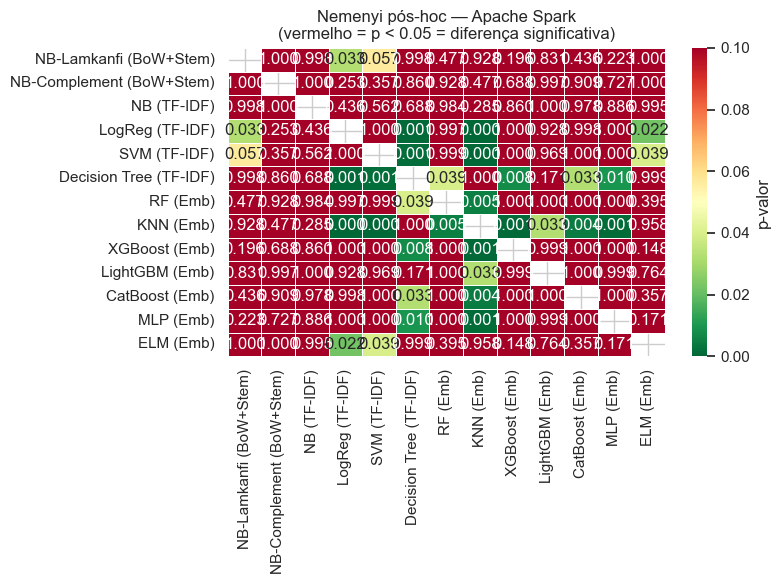


=== Seleção de Modelos — CIRCL CVE | métrica: F1-macro ===
                  Modelo  Rank médio  F1-macro médio
            SVM (TF-IDF)         1.6          0.7066
         LogReg (TF-IDF)         2.7          0.6969
  Decision Tree (TF-IDF)         4.3          0.6787
  NB-Lamkanfi (BoW+Stem)         4.8          0.6739
NB-Complement (BoW+Stem)         4.9          0.6723
          LightGBM (Emb)         6.1          0.6615
               MLP (Emb)         7.2          0.6524
                RF (Emb)         7.8          0.6445
           XGBoost (Emb)         7.8          0.6432
             NB (TF-IDF)         8.4          0.6407
          CatBoost (Emb)        10.6          0.6128
               ELM (Emb)        12.0          0.5690
               KNN (Emb)        12.8          0.5387

Friedman: χ²=92.2286, p=0.000000
  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc

Matrix p-valores (Nemenyi):
                          NB-Lamkanfi (BoW+Stem)  NB-Complement (BoW+Stem)  NB (TF

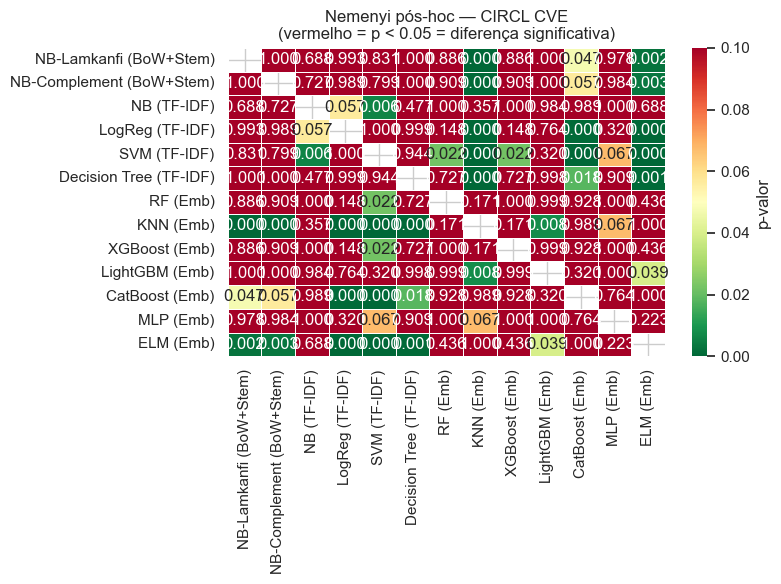

In [18]:
def selecao_modelos(results_dict, dataset_name, metrica='F1-macro'):
    nomes  = list(results_dict.keys())
    scores = np.array([results_dict[n]['folds'][metrica].values for n in nomes])

    print(f'\n=== Seleção de Modelos — {dataset_name} | métrica: {metrica} ===')

    # Ranking médio
    ranks = np.array([(-scores[:, f]).argsort().argsort() + 1
                      for f in range(scores.shape[1])]).T
    mean_ranks = ranks.mean(axis=1)
    rank_df = pd.DataFrame({
        'Modelo': nomes,
        'Rank médio': mean_ranks.round(2),
        f'{metrica} médio': scores.mean(axis=1).round(4),
    }).sort_values('Rank médio').reset_index(drop=True)
    print(rank_df.to_string(index=False))

    # Friedman
    stat, p = friedmanchisquare(*[scores[i] for i in range(len(nomes))])
    print(f'\nFriedman: χ²={stat:.4f}, p={p:.6f}')
    if p >= 0.05:
        print('  p ≥ 0.05 → sem diferença significativa entre os modelos.')
        return rank_df, None
    print('  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc')

    # Nemenyi
    scores_df = pd.DataFrame(scores.T, columns=nomes)
    p_nem = sp.posthoc_nemenyi_friedman(scores_df)
    print('\nMatrix p-valores (Nemenyi):')
    print(p_nem.round(4).to_string())

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(p_nem, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.1, mask=np.eye(len(nomes), dtype=bool),
                ax=ax, linewidths=0.5, cbar_kws={'label': 'p-valor'})
    ax.set_title(f'Nemenyi pós-hoc — {dataset_name}\n(vermelho = p < 0.05 = diferença significativa)')
    plt.tight_layout()
    fname = f'nemenyi_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return rank_df, p_nem


rank_spark, nem_spark = selecao_modelos(results_spark, 'Apache Spark')
rank_circl, nem_circl = selecao_modelos(results_circl, 'CIRCL CVE')

---
### Seção 8.0 — Registry compartilhado de base-learners

Antes de selecionar e combinar modelos, definimos um **registry/factory único** que, dado o nome de um baseline, instancia uma cópia nova e não-treinada do estimador com os hiperparâmetros ajustados na Seção 6.5 e informa qual representação ele consome (TF-IDF ou Embeddings). Tanto a seleção dinâmica (Seção 8.1) quanto os ensembles **Stacking** (Seção 9) e **Voto Ponderado** (Seção 9.1) usam este mesmo registry, evitando duplicação de código e garantindo que todos operem exatamente sobre os mesmos modelos.

In [19]:
def reorder_proba(proba, clf_classes, target_classes):
    cls_list = list(clf_classes)
    idx = [cls_list.index(c) for c in target_classes if c in cls_list]
    return proba[:, idx]


# ════════════════════════════════════════════════════════════════════════════
#  Registry/Factory compartilhado de base-learners
#  Usado tanto por evaluate_stacking() (Meta-learning) quanto por
#  run_weighted_voting() (Fusão), garantindo que ambos os ensembles utilizem
#  EXATAMENTE os mesmos modelos e hiperparâmetros (busca_hiperparametros()).
#  Para um nome de baseline, devolve:
#    - rep      : representação ('text' = TF-IDF | 'emb' = embeddings)
#    - needs_le : se o estimador exige rótulos inteiros (LabelEncoder) em vez de
#                 strings (caso de XGBoost e CatBoost)
# ════════════════════════════════════════════════════════════════════════════

def _make_base_learner(name, p, seed=SEED):
    """Instancia um base-learner fresco (não-treinado) a partir do nome.

    Reaproveita as MESMAS chaves/defaults de p.get(...) usadas em build_baselines()
    (Seção 7), evitando divergência entre baseline e ensemble.
    Retorna (estimator, rep, needs_le).
    """
    p = p or {}
    if name == 'NB (TF-IDF)':
        return ComplementNB(alpha=p.get('nb_alpha', 1.0)), 'text', False
    if name == 'LogReg (TF-IDF)':
        return (LogisticRegression(max_iter=1000, C=p.get('logreg_C', 1.0),
                                   random_state=seed), 'text', False)
    if name == 'SVM (TF-IDF)':
        return (CalibratedClassifierCV(
                    LinearSVC(max_iter=3000, C=p.get('svm_C', 1.0), random_state=seed),
                    cv=3), 'text', False)
    if name == 'Decision Tree (TF-IDF)':
        return (DecisionTreeClassifier(
                    max_depth=p.get('dt_depth', 10), min_samples_split=p.get('dt_split', 2),
                    criterion=p.get('dt_crit', 'gini'), random_state=seed), 'text', False)
    if name == 'RF (Emb)':
        return (RandomForestClassifier(
                    n_estimators=p.get('rf_n', 300), max_depth=p.get('rf_depth', None),
                    random_state=seed, n_jobs=-1), 'emb', False)
    if name == 'KNN (Emb)':
        from sklearn.pipeline import Pipeline as _SkPipe
        return (_SkPipe([
            ('pca', PCA(n_components=200, random_state=seed)),
            ('clf', KNeighborsClassifier(
                        n_neighbors=p.get('knn_n', 5),
                        weights=p.get('knn_weights', 'uniform'))),
        ]), 'emb', False)
    if name == 'XGBoost (Emb)':
        return (XGBClassifier(
                    n_estimators=p.get('xgb_n', 200), learning_rate=p.get('xgb_lr', 0.1),
                    max_depth=p.get('xgb_d', 6), eval_metric='mlogloss',
                    random_state=seed, verbosity=0, **XGB_GPU), 'emb', True)
    if name == 'LightGBM (Emb)':
        return (LGBMClassifier(
                    n_estimators=p.get('lgbm_n', 200), learning_rate=p.get('lgbm_lr', 0.1),
                    num_leaves=p.get('lgbm_leaves', 31), random_state=seed,
                    verbose=-1, **LGBM_GPU), 'emb', False)
    if name == 'CatBoost (Emb)':
        return (CatBoostClassifier(
                    depth=p.get('catboost_depth', 6), learning_rate=p.get('catboost_lr', 0.1),
                    iterations=p.get('catboost_iter', 200), random_state=seed,
                    verbose=False, **CATBOOST_GPU), 'emb', True)
    if name == 'MLP (Emb)':
        return (MLPClassifier(
                    hidden_layer_sizes=p.get('mlp_hidden', (128,)),
                    alpha=p.get('mlp_alpha', 1e-4), max_iter=300, random_state=seed),
                'emb', False)
    if name == 'ELM (Emb)':
        return (ELMClassifier(
                    hidden_neurons=p.get('elm_hidden', 500), random_state=seed),
                'emb', False)
    raise ValueError('Base-learner desconhecido: ' + repr(name))


def _base_rep(name, p, seed=SEED):
    """Devolve apenas a representação ('text'/'emb') de um base-learner."""
    return _make_base_learner(name, p, seed)[1]


def _fit_predict_proba(name, p, X_tr, y_tr, X_te, sm, le, classes, seed=SEED):
    """Treina UM base-learner (com SMOTE) e devolve predict_proba alinhado a `classes`.

    Trata a necessidade de LabelEncoder (XGBoost/CatBoost — não aceitam rótulos
    string) e reordena as colunas de probabilidade via reorder_proba para casar
    com a ordem de CLASSES.
    """
    est, _, needs_le = _make_base_learner(name, p, seed)
    if needs_le:
        Xs, ys = sm.fit_resample(X_tr, le.transform(y_tr))
        est.fit(Xs, ys)
        # le.classes_ segue ordem alfabética (LabelEncoder), que diverge da ordem
        # de `classes` (CLASSES) — é preciso reordenar as colunas de proba.
        return reorder_proba(est.predict_proba(X_te), le.classes_, classes)
    Xs, ys = sm.fit_resample(X_tr, y_tr)
    est.fit(Xs, ys)
    return reorder_proba(est.predict_proba(X_te), est.classes_, classes)

print("Registry de base-learners (compartilhado Stacking/Voto) definido.")

Registry de base-learners (compartilhado Stacking/Voto) definido.


---
### Seção 8.1 — Decisão de composição do ensemble (pós-Nemenyi)

Esta célula **deriva automaticamente** quais baselines comporão os ensembles
(Stacking e Voto Ponderado) a partir dos resultados estatísticos da Seção 8 — a
composição **não é fixada a priori**, ela emerge dos dados de cada dataset.

**Método (genérico, calculado em tempo de execução):**

1. Os modelos são percorridos em ordem crescente de **rank médio** (melhor primeiro);
   o melhor é sempre incluído.
2. Um modelo é **excluído** quando o teste de **Nemenyi** indica que ele é
   *estatisticamente equivalente* (p > 0,05) a um modelo **já selecionado, de melhor
   rank e da mesma representação** (TF-IDF *ou* Embeddings) — ou seja, é redundante
   dentro da sua família. Preservamos assim a **diversidade de representação**,
   descartando apenas a redundância genuína.
3. Se o **Friedman** não acusar diferença significativa (p ≥ 0,05), o Nemenyi não se
   aplica e recorremos a um *fallback*: os top-N por rank médio.

Como a decisão é puramente data-driven, **Spark e CIRCL podem selecionar subconjuntos
diferentes** — o que é esperado e tratado independentemente no restante do notebook.
A lista resultante alimenta tanto o `evaluate_stacking` (Meta-learning) quanto o
`run_weighted_voting` (Fusão), garantindo uma comparação justa sobre os **mesmos**
base-learners. Isso atende ao requisito de *especificação do processo de seleção de
modelos*.

In [20]:
def _rep_of(nome, params=None):
    """Representação ('text'/'emb') de um baseline pelo nome — via registry da Seção 9."""
    return _base_rep(nome, params)


# RF, XGBoost, LightGBM, CatBoost são ensembles — ficam só como benchmark.
# Incluí-los no stacking criaria ensemble-de-ensemble sem justificativa (Lorenzato, 2024).
_ENSEMBLE_ONLY = frozenset({
    'RF (Emb)', 'XGBoost (Emb)', 'LightGBM (Emb)', 'CatBoost (Emb)',
    'NB-Lamkanfi (BoW+Stem)',     # BoW+stem não tem path no stacking (só TF-IDF ou Emb)
    'NB-Complement (BoW+Stem)',   # idem — variante de investigação, só benchmark
})


def seleciona_base_learners(rank_df, p_nem, dataset_name,
                            top_n_fallback=5, alpha=0.05, params=None):
    """Seleciona DINAMICAMENTE o subconjunto de base-learners para o ensemble.

    Regra (quando o Friedman foi significativo e há matriz Nemenyi `p_nem`):
      1. Percorre os modelos em ordem CRESCENTE de rank médio (melhor primeiro).
      2. O melhor modelo é sempre incluído.
      3. Um modelo é EXCLUÍDO se for estatisticamente equivalente (Nemenyi p > alpha)
         a algum modelo JÁ SELECIONADO de MESMA representação (TF-IDF vs Embeddings)
         e melhor rank — ou seja, é redundante dentro da sua família.
      4. Caso contrário é incluído (traz diversidade: ou é de outra representação,
         ou é significativamente distinto dos já escolhidos da mesma família).

    Se Friedman NÃO foi significativo (p_nem is None), não há base para afirmar
    redundância → fallback: top-N por rank médio.

    Retorna (selected:list[str], reasoning:list[str]).
    """
    nomes_ord = rank_df['Modelo'].tolist()  # já ordenado por rank médio
    reasoning = []

    # ── 0. Excluir a priori modelos que já são ensembles (só benchmark) ──
    ens_excl  = [n for n in nomes_ord if n in _ENSEMBLE_ONLY]
    nomes_ord = [n for n in nomes_ord if n not in _ENSEMBLE_ONLY]
    for n in ens_excl:
        reasoning.append(f'  ✗ {n}: excluído do stacking — já é ensemble (só benchmark).')
    if ens_excl:
        print('  Excluídos a priori (ensembles — só benchmark):', ens_excl)

    print(f'\n=== Seleção dinâmica de base-learners — {dataset_name} ===')

    if p_nem is None:
        selected = nomes_ord[:top_n_fallback]
        reasoning.append(
            f'Friedman não-significativo → Nemenyi não se aplica; fallback para os '
            f'top-{top_n_fallback} por rank médio.')
        for n in selected:
            reasoning.append(f'  + {n} incluído (top-{top_n_fallback} por rank).')
        print('\n'.join(reasoning))
        print(f'\nSelecionados ({len(selected)}): {selected}')
        return selected, reasoning

    selected = []
    for nome in nomes_ord:
        rep = _rep_of(nome, params)
        redundante_com = None
        for sel in selected:                       # já-selecionados têm rank melhor
            if _rep_of(sel, params) != rep:
                continue                           # representação diferente → não redundante
            pval = float(p_nem.loc[nome, sel])
            if pval > alpha:                       # equivalente estatisticamente
                redundante_com = (sel, pval)
                break
        if redundante_com is None:
            selected.append(nome)
            reasoning.append(
                f'  + {nome} incluído  (rep={rep}; distinto/diverso dos já selecionados).')
        else:
            sel, pval = redundante_com
            reasoning.append(
                f'  - {nome} excluído: equivalente a {sel} (Nemenyi p={pval:.3f} > {alpha}), '
                f'mesma representação ({rep}).')

    # Salvaguarda: o ensemble precisa de pelo menos 2 modelos
    if len(selected) < 2:
        extra = [n for n in nomes_ord if n not in selected][:2 - len(selected)]
        selected += extra
        for n in extra:
            reasoning.append(f'  + {n} incluído  (salvaguarda: mínimo de 2 base-learners).')

    print('\n'.join(reasoning))
    reps = sorted({_rep_of(n, params) for n in selected})
    print(f'\nSelecionados ({len(selected)}): {selected}')
    print(f'Representações cobertas: {reps}'
          + ('  [HÍBRIDO: TF-IDF + Embeddings]' if len(reps) > 1 else '  [única representação]'))
    return selected, reasoning


sel_spark, just_spark = seleciona_base_learners(rank_spark, nem_spark, 'Apache Spark',
                                                params=bp_spark)
sel_circl, just_circl = seleciona_base_learners(rank_circl, nem_circl, 'CIRCL CVE',
                                                params=bp_circl)

  Excluídos a priori (ensembles — só benchmark): ['XGBoost (Emb)', 'CatBoost (Emb)', 'RF (Emb)', 'LightGBM (Emb)', 'NB-Complement (BoW+Stem)', 'NB-Lamkanfi (BoW+Stem)']

=== Seleção dinâmica de base-learners — Apache Spark ===
  ✗ XGBoost (Emb): excluído do stacking — já é ensemble (só benchmark).
  ✗ CatBoost (Emb): excluído do stacking — já é ensemble (só benchmark).
  ✗ RF (Emb): excluído do stacking — já é ensemble (só benchmark).
  ✗ LightGBM (Emb): excluído do stacking — já é ensemble (só benchmark).
  ✗ NB-Complement (BoW+Stem): excluído do stacking — já é ensemble (só benchmark).
  ✗ NB-Lamkanfi (BoW+Stem): excluído do stacking — já é ensemble (só benchmark).
  + LogReg (TF-IDF) incluído  (rep=text; distinto/diverso dos já selecionados).
  - SVM (TF-IDF) excluído: equivalente a LogReg (TF-IDF) (Nemenyi p=1.000 > 0.05), mesma representação (text).
  + MLP (Emb) incluído  (rep=emb; distinto/diverso dos já selecionados).
  - NB (TF-IDF) excluído: equivalente a LogReg (TF-IDF) (Nem

---
## Seção 9 — Sistema Híbrido: Stacking com OOF Aninhado

### Onde acontece a hibridização?

A hibridização ocorre **na montagem das meta-features**. O `evaluate_stacking` recebe
a lista `base_learners` **escolhida dinamicamente na Seção 8.1** e monta uma matriz de
meta-features com `len(base_learners) × 3` colunas — um bloco de `P(Alta), P(Méd), P(Bx)`
por base-learner selecionado.

```
Meta-features (3 colunas por base-learner selecionado):
  bloco do modelo j  → P(Alta), P(Méd), P(Bx)
     · modelos TF-IDF  → frequência de termos (esparso, linear)
     · modelos Embeddings → semântica densa (1024 dim, não-linear)
                                ▼
            LogReg (meta, C=0.1) aprende o peso ideal de cada fonte por classe
```

Quando a seleção mistura modelos TF-IDF e Embeddings, o meta-classificador vê **ambas
as representações** simultaneamente — é aí que a hibridização emerge. O meta-LogReg não
"vê" o texto diretamente; ele vê a **confiança de cada modelo base** e aprende quando
confiar mais no TF-IDF (palavras-chave exatas) e quando confiar mais nos embeddings
(semântica e paráfrases).

> Os blocos não são mais fixos em 4 modelos: a composição depende do que a Seção 8.1
> selecionou para cada dataset (Spark e CIRCL podem diferir).

### Anti-leakage: predições Out-of-Fold (OOF)

As meta-features de treino são geradas com **inner CV** (5 folds):
cada amostra é predita por um modelo que **não a viu** no treino.

O SMOTE é aplicado:
- Dentro de cada **inner fold** para os modelos base
- Nos **meta-features OOF** para o meta-classificador
- Nunca nos dados de **teste**

Os hiperparâmetros dos modelos base vêm do `bp_spark` / `bp_circl` (Seção 6.5),
instanciados pelo registry compartilhado (Seção 8.0).

In [21]:
def evaluate_stacking(df, emb, base_learners, params=None, classes=CLASSES,
                      n_outer=N_OUTER, n_inner=N_INNER, seed=SEED):
    """Stacking (Meta-learning) com nested CV sobre uma lista ARBITRÁRIA de base-learners.

    base_learners: lista de nomes (chaves de build_baselines) escolhidos
                   dinamicamente pela seleção pós-Nemenyi (Seção 8). A largura da
                   matriz de meta-features é len(base_learners) * n_cls.

    Nível 0: cada nome em `base_learners`, na sua representação própria
             (TF-IDF ou Embeddings).
    Nível 1: LogReg (C=0.1) treinado nas predições OOF.

    A HIBRIDIZAÇÃO ocorre quando base_learners mistura modelos 'text' (TF-IDF)
    e 'emb' (Embeddings): o meta-LogReg vê ambas as fontes simultaneamente e
    aprende o peso ideal de cada uma por classe.

    params: dict de busca_hiperparametros(); se None usa defaults.
    """
    if not base_learners:
        raise ValueError('base_learners não pode ser vazio.')
    p     = params or {}
    n_sel = len(base_learners)

    texts    = df['text'].tolist()
    y        = df['label'].values
    le       = LabelEncoder().fit(classes)
    n_cls    = len(classes)
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=seed)
    records, y_true_all, y_pred_all = [], [], []

    print(f'  Base-learners ({n_sel}): {", ".join(base_learners)}')

    for fold, (o_tr, o_te) in enumerate(outer_cv.split(emb, y), 1):
        print(f'  Fold {fold}/{n_outer}...', end=' ', flush=True)

        txt_tr = [texts[i] for i in o_tr];  txt_te = [texts[i] for i in o_te]
        emb_tr = emb[o_tr];                 emb_te = emb[o_te]
        y_tr   = y[o_tr];                   y_te   = y[o_te]

        tfidf  = TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)
        scaler = StandardScaler()
        X_tfidf_tr = tfidf.fit_transform(txt_tr);  X_tfidf_te = tfidf.transform(txt_te)
        X_emb_tr   = scaler.fit_transform(emb_tr); X_emb_te   = scaler.transform(emb_te)

        def _rep(name, te=False):
            if _base_rep(name, p, seed) == 'text':
                return X_tfidf_te if te else X_tfidf_tr
            return X_emb_te if te else X_emb_tr

        # ── Inner CV: gerar OOF meta-features ────────────────────────────────
        oof = np.zeros((len(o_tr), n_sel * n_cls))
        for i_tr, i_te in inner_cv.split(X_emb_tr, y_tr):
            k  = safe_k(y_tr[i_tr])
            sm = SMOTE(random_state=seed, k_neighbors=k)
            for j, name in enumerate(base_learners):
                Xrep  = _rep(name)
                proba = _fit_predict_proba(
                    name, p, Xrep[i_tr], y_tr[i_tr], Xrep[i_te], sm, le, classes, seed)
                oof[i_te, j*n_cls:(j+1)*n_cls] = proba

        # ── Meta-classificador: treina nas OOF ────────────────────────────────
        sm_meta = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))
        oof_s, y_s = sm_meta.fit_resample(oof, y_tr)
        meta_clf = LogisticRegression(max_iter=1000, C=0.1, random_state=seed).fit(oof_s, y_s)

        # ── Level 0: modelos finais no outer-train + meta-features do teste ───
        sm_full = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))
        test_meta = np.zeros((len(o_te), n_sel * n_cls))
        for j, name in enumerate(base_learners):
            Xtr = _rep(name); Xte = _rep(name, te=True)
            proba = _fit_predict_proba(name, p, Xtr, y_tr, Xte, sm_full, le, classes, seed)
            test_meta[:, j*n_cls:(j+1)*n_cls] = proba

        y_pred = meta_clf.predict(test_meta)
        y_true_all.extend(y_te); y_pred_all.extend(y_pred)
        m = compute_metrics(y_te, y_pred)
        records.append(m)
        print(f'F1-macro={m["F1-macro"]:.4f}')

    folds_df = pd.DataFrame(records)
    return {'folds': folds_df, 'summary': folds_df.agg(['mean','std']),
            'y_true': np.array(y_true_all), 'y_pred': np.array(y_pred_all)}

print('evaluate_stacking + registry de base-learners definidos.')

evaluate_stacking + registry de base-learners definidos.


In [22]:
print('=== Stacking — Apache Spark ===')
result_stack_spark = evaluate_stacking(df_spark_eval, emb_spark_eval, base_learners=sel_spark,
                                       params=bp_spark)
print_summary(result_stack_spark, 'Stacking (Spark)')

print('\n=== Stacking — CIRCL CVE ===')
result_stack_circl = evaluate_stacking(df_circl_eval, emb_circl_eval, base_learners=sel_circl,
                                       params=bp_circl)
print_summary(result_stack_circl, 'Stacking (CIRCL)')

=== Stacking — Apache Spark ===
  Base-learners (4): LogReg (TF-IDF), MLP (Emb), Decision Tree (TF-IDF), KNN (Emb)
  Fold 1/10... F1-macro=0.4784
  Fold 2/10... F1-macro=0.5091
  Fold 3/10... F1-macro=0.4941
  Fold 4/10... F1-macro=0.5058
  Fold 5/10... F1-macro=0.5334
  Fold 6/10... F1-macro=0.5486
  Fold 7/10... F1-macro=0.5041
  Fold 8/10... F1-macro=0.5059
  Fold 9/10... F1-macro=0.5739
  Fold 10/10... F1-macro=0.4998

── Stacking (Spark) ──
  F1-macro    : 0.5153 ± 0.0284
  Acurácia    : 0.5316 ± 0.0280
  Precisão    : 0.5139 ± 0.0271
  Recall      : 0.5471 ± 0.0301
  MCC         : 0.2797 ± 0.0440
  Kappa       : 0.2745 ± 0.0434
  F1-Alta     : 0.4403 ± 0.0361
  F1-Média    : 0.5121 ± 0.0355
  F1-Baixa    : 0.5935 ± 0.0392

=== Stacking — CIRCL CVE ===
  Base-learners (3): SVM (TF-IDF), MLP (Emb), NB (TF-IDF)
  Fold 1/10... F1-macro=0.7448
  Fold 2/10... F1-macro=0.6881
  Fold 3/10... F1-macro=0.6817
  Fold 4/10... F1-macro=0.6816
  Fold 5/10... F1-macro=0.6820
  Fold 6/10... F1-m

---
## Seção 9.1 — Sistema de Fusão: Voto Suave Ponderado

A Aula 09 (Lorenzato, RecPad) define três famílias de ensemble: **Fusão**,
**Seleção** e **Meta-learning**. A Seção 9 implementa Meta-learning (Stacking).
Aqui adicionamos a estratégia de **Fusão** — *voto suave ponderado* — sobre **os
mesmos base-learners selecionados** na Seção 8.1, permitindo uma comparação direta
**Meta-learning × Fusão** com base idêntica.

**Como funciona:** para cada fold externo, cada base-learner é treinado (com SMOTE) e
produz probabilidades por classe. O peso de cada modelo é a sua **F1-macro de validação
interna** (split interno estratificado), normalizada:

$$w_i = \frac{f1_i}{\sum_j f1_j}, \qquad P_{final} = \sum_i w_i \cdot P_i$$

A classe final é o `argmax` de $P_{final}$. Diferente do Stacking, **não há
meta-classificador treinável** — a combinação é uma média ponderada fixa, mais simples.
A hipótese científica é que o Stacking, por aprender pesos por classe, supere a Fusão.

In [23]:
def run_weighted_voting(df, emb, dataset_name, base_learners, params=None,
                        classes=CLASSES, n_outer=N_OUTER, seed=SEED):
    """Fusão por Voto Suave Ponderado sobre os MESMOS base_learners do Stacking.

    Para cada fold externo:
      - treina cada base-learner (com SMOTE) no outer-train e prediz proba no outer-test;
      - estima o peso de cada modelo via F1-macro de uma validação interna simples
        (um único split estratificado interno), normalizada: w_i = f1_i / sum(f1_j);
      - combina: P_final = sum(w_i * P_i); classe = argmax(P_final).

    Reaproveita o registry compartilhado (_make_base_learner/_fit_predict_proba),
    sem duplicar a construção dos modelos. Retorna o mesmo dict-shape dos demais
    avaliadores (folds/summary/y_true/y_pred).
    """
    if not base_learners:
        raise ValueError('base_learners não pode ser vazio.')
    p        = params or {}
    texts    = df['text'].tolist()
    y        = df['label'].values
    le       = LabelEncoder().fit(classes)
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    records, y_true_all, y_pred_all = [], [], []

    print(f'\n=== Voto Ponderado (Fusão) — {dataset_name} ===')
    print(f'  Base-learners ({len(base_learners)}): {", ".join(base_learners)}')

    for fold, (o_tr, o_te) in enumerate(outer_cv.split(emb, y), 1):
        print(f'  Fold {fold}/{n_outer}...', end=' ', flush=True)

        txt_tr = [texts[i] for i in o_tr];  txt_te = [texts[i] for i in o_te]
        emb_tr = emb[o_tr];                 emb_te = emb[o_te]
        y_tr   = y[o_tr];                   y_te   = y[o_te]

        tfidf  = TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)
        scaler = StandardScaler()
        X_tfidf_tr = tfidf.fit_transform(txt_tr);  X_tfidf_te = tfidf.transform(txt_te)
        X_emb_tr   = scaler.fit_transform(emb_tr); X_emb_te   = scaler.transform(emb_te)

        def _rep(name, te=False):
            if _base_rep(name, p, seed) == 'text':
                return X_tfidf_te if te else X_tfidf_tr
            return X_emb_te if te else X_emb_tr

        # ── Split interno único para estimar o peso (F1-macro) de cada modelo ─
        inner = StratifiedKFold(n_splits=2, shuffle=True, random_state=seed)
        i_tr, i_va = next(iter(inner.split(X_emb_tr, y_tr)))
        k_in = safe_k(y_tr[i_tr]); sm_in = SMOTE(random_state=seed, k_neighbors=k_in)

        weights, probas = [], []
        sm_full = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))
        for name in base_learners:
            Xrep = _rep(name)
            # peso: F1-macro do modelo na validação interna
            proba_va = _fit_predict_proba(
                name, p, Xrep[i_tr], y_tr[i_tr], Xrep[i_va], sm_in, le, classes, seed)
            y_va_pred = np.array(classes)[proba_va.argmax(axis=1)]
            f1_in = f1_score(y_tr[i_va], y_va_pred, average='macro', zero_division=0)

            # proba no outer-test (modelo treinado no outer-train completo)
            proba_te = _fit_predict_proba(
                name, p, Xrep, y_tr, _rep(name, te=True), sm_full, le, classes, seed)
            weights.append(max(f1_in, 1e-6))
            probas.append(proba_te)

        w = np.array(weights); w = w / w.sum()
        final_proba = sum(wi * pi for wi, pi in zip(w, probas))
        y_pred = np.array(classes)[final_proba.argmax(axis=1)]

        y_true_all.extend(y_te); y_pred_all.extend(y_pred)
        m = compute_metrics(y_te, y_pred)
        records.append(m)
        print(f'F1-macro={m["F1-macro"]:.4f} | pesos={np.round(w, 3)}')

    folds_df = pd.DataFrame(records)
    return {'folds': folds_df, 'summary': folds_df.agg(['mean','std']),
            'y_true': np.array(y_true_all), 'y_pred': np.array(y_pred_all)}

print('run_weighted_voting definida.')

run_weighted_voting definida.


In [24]:
result_voting_spark = run_weighted_voting(df_spark_eval, emb_spark_eval, 'Apache Spark',
                                         base_learners=sel_spark, params=bp_spark)
print_summary(result_voting_spark, 'Voto Ponderado (Spark)')

result_voting_circl = run_weighted_voting(df_circl_eval, emb_circl_eval, 'CIRCL CVE',
                                          base_learners=sel_circl, params=bp_circl)
print_summary(result_voting_circl, 'Voto Ponderado (CIRCL)')


=== Voto Ponderado (Fusão) — Apache Spark ===
  Base-learners (4): LogReg (TF-IDF), MLP (Emb), Decision Tree (TF-IDF), KNN (Emb)
  Fold 1/10... F1-macro=0.4969 | pesos=[0.28  0.273 0.242 0.206]
  Fold 2/10... F1-macro=0.5003 | pesos=[0.278 0.269 0.237 0.216]
  Fold 3/10... F1-macro=0.4939 | pesos=[0.273 0.263 0.235 0.229]
  Fold 4/10... F1-macro=0.4931 | pesos=[0.276 0.267 0.238 0.22 ]
  Fold 5/10... F1-macro=0.5569 | pesos=[0.276 0.266 0.234 0.224]
  Fold 6/10... F1-macro=0.5182 | pesos=[0.279 0.267 0.236 0.217]
  Fold 7/10... F1-macro=0.4972 | pesos=[0.268 0.279 0.238 0.215]
  Fold 8/10... F1-macro=0.5043 | pesos=[0.279 0.264 0.237 0.22 ]
  Fold 9/10... F1-macro=0.5749 | pesos=[0.269 0.262 0.245 0.223]
  Fold 10/10... F1-macro=0.5025 | pesos=[0.277 0.271 0.233 0.219]

── Voto Ponderado (Spark) ──
  F1-macro    : 0.5138 ± 0.0287
  Acurácia    : 0.5420 ± 0.0252
  Precisão    : 0.5129 ± 0.0293
  Recall      : 0.5187 ± 0.0289
  MCC         : 0.2631 ± 0.0386
  Kappa       : 0.2623 ± 0.03

---
## Seção 9.2 — Combinação Dinâmica de Classificadores

Para cada ponto de teste:
1. **OOF** — predições de cada base-learner no outer-train coletadas via 5-fold interno.
2. **KNN** — K vizinhos mais próximos no espaço de predições OOF (concatenação das probabilidades de todos os modelos).
3. **MQ local** — pesos calculados por mínimos quadrados (pseudo-inversa) sobre os K vizinhos: `W = pinv(X_vizinhos) @ y_vizinhos_onehot`.
4. **Predição** — combinação ponderada das probabilidades do ponto de teste: `proba = x_teste @ W`.

Baseado no exercício de aula *Combinação Ponderada* (Lorenzato, 2024).

In [25]:
def run_combinacao_dinamica(df, emb, dataset_name, base_learners, params=None,
                              classes=CLASSES, n_outer=N_OUTER, seed=SEED, k_dyn=7):
    """Combinação Dinâmica de Classificadores (KNN + MQ local).

    Para cada ponto de teste, encontra K vizinhos no espaço de predições OOF
    e calcula pesos locais por mínimos quadrados (pseudo-inversa), adaptando
    o exercício de aula (Lorenzato, 2024) para classificação multi-classe.
    """
    if not base_learners:
        raise ValueError('base_learners nao pode ser vazio.')
    p      = params or {}
    texts  = df['text'].tolist()
    y      = df['label'].values
    le     = LabelEncoder().fit(classes)
    n_cls  = len(classes)
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    records, y_true_all, y_pred_all = [], [], []

    print(f'\n=== Combinacao Dinamica --- {dataset_name} ===')
    print(f'  Base-learners ({len(base_learners)}): {", ".join(base_learners)}')

    for fold, (o_tr, o_te) in enumerate(outer_cv.split(emb, y), 1):
        print(f'  Fold {fold}/{n_outer}...', end=' ', flush=True)

        txt_tr = [texts[i] for i in o_tr]; txt_te = [texts[i] for i in o_te]
        emb_tr = emb[o_tr];                emb_te = emb[o_te]
        y_tr   = y[o_tr];                  y_te   = y[o_te]

        tfidf  = TfidfVectorizer(max_features=20_000, sublinear_tf=True, tokenizer=_lamkanfi_tokenizer)
        scaler = StandardScaler()
        X_tfidf_tr = tfidf.fit_transform(txt_tr); X_tfidf_te = tfidf.transform(txt_te)
        X_emb_tr   = scaler.fit_transform(emb_tr); X_emb_te  = scaler.transform(emb_te)

        def _rep(name, te=False):
            if _base_rep(name, p, seed) == 'text':
                return X_tfidf_te if te else X_tfidf_tr
            return X_emb_te if te else X_emb_tr

        n_train  = len(o_tr)
        n_learn  = len(base_learners)
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        # ── OOF: predicoes dos base-learners no treino (5-fold interno) ───────
        oof_probas = [np.zeros((n_train, n_cls)) for _ in range(n_learn)]
        for _, (tr_i, va_i) in enumerate(inner_cv.split(X_emb_tr, y_tr)):
            k_in  = safe_k(y_tr[tr_i])
            sm_in = SMOTE(random_state=seed, k_neighbors=k_in)
            for j, name in enumerate(base_learners):
                proba = _fit_predict_proba(
                    name, p,
                    _rep(name)[tr_i], y_tr[tr_i],
                    _rep(name)[va_i], sm_in, le, classes, seed)
                oof_probas[j][va_i] = proba

        # X_oof: (n_train, n_learn * n_cls) — espaco de predicoes OOF
        X_oof    = np.hstack(oof_probas)
        y_oof_oh = np.eye(n_cls)[le.transform(y_tr)]  # (n_train, n_cls)

        # ── Treinar modelos no outer-train completo para predizer no teste ────
        sm_full = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))
        test_probas_list = []
        for _, name in enumerate(base_learners):
            proba_te = _fit_predict_proba(
                name, p, _rep(name), y_tr, _rep(name, te=True), sm_full, le, classes, seed)
            test_probas_list.append(proba_te)
        X_test = np.hstack(test_probas_list)  # (n_test, n_learn * n_cls)

        # ── KNN + MQ local ────────────────────────────────────────────────────
        k_eff = min(k_dyn, n_train)
        knn   = NearestNeighbors(n_neighbors=k_eff, metric='euclidean')
        knn.fit(X_oof)

        y_pred_fold = []
        for t in range(len(o_te)):
            _, idxs = knn.kneighbors(X_test[t].reshape(1, -1))
            idxs    = idxs[0]
            X_neigh = X_oof[idxs]       # (k, n_learn * n_cls)
            y_neigh = y_oof_oh[idxs]    # (k, n_cls)
            W       = np.linalg.pinv(X_neigh) @ y_neigh  # (n_learn*n_cls, n_cls)
            proba   = X_test[t] @ W      # (n_cls,)
            proba   = np.clip(proba, 0, None)
            s       = proba.sum()
            proba   = proba / s if s > 0 else np.ones(n_cls) / n_cls
            y_pred_fold.append(classes[proba.argmax()])

        y_pred  = np.array(y_pred_fold)
        metrics = compute_metrics(y_te, y_pred, classes)
        records.append(metrics)
        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        print(f'F1-macro={metrics["F1-macro"]:.4f}')

    df_folds   = pd.DataFrame(records)
    summary    = df_folds.agg(['mean', 'std'])
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    print(f'  Media F1-macro: {summary.loc["mean","F1-macro"]:.4f} +/- {summary.loc["std","F1-macro"]:.4f}')
    return {'folds': df_folds, 'summary': summary, 'y_true': y_true_all, 'y_pred': y_pred_all}

print('Combinacao Dinamica (Secao 9.2) definida.')

Combinacao Dinamica (Secao 9.2) definida.


In [26]:
result_comb_spark = run_combinacao_dinamica(df_spark_eval, emb_spark_eval, 'Apache Spark',
                                               base_learners=sel_spark, params=bp_spark)
print_summary(result_comb_spark, 'Comb. Dinamica (Spark)')

result_comb_circl = run_combinacao_dinamica(df_circl_eval, emb_circl_eval, 'CIRCL CVE',
                                            base_learners=sel_circl, params=bp_circl)
print_summary(result_comb_circl, 'Comb. Dinamica (CIRCL)')


=== Combinacao Dinamica --- Apache Spark ===
  Base-learners (4): LogReg (TF-IDF), MLP (Emb), Decision Tree (TF-IDF), KNN (Emb)
  Fold 1/10... F1-macro=0.3323
  Fold 2/10... F1-macro=0.3712
  Fold 3/10... F1-macro=0.3292
  Fold 4/10... F1-macro=0.3831
  Fold 5/10... F1-macro=0.2940
  Fold 6/10... F1-macro=0.3518
  Fold 7/10... F1-macro=0.4005
  Fold 8/10... F1-macro=0.3966
  Fold 9/10... F1-macro=0.3247
  Fold 10/10... F1-macro=0.3637
  Media F1-macro: 0.3547 +/- 0.0346

── Comb. Dinamica (Spark) ──
  F1-macro    : 0.3547 ± 0.0346
  Acurácia    : 0.3770 ± 0.0410
  Precisão    : 0.3545 ± 0.0373
  Recall      : 0.3596 ± 0.0324
  MCC         : 0.0022 ± 0.0585
  Kappa       : 0.0022 ± 0.0582
  F1-Alta     : 0.2688 ± 0.0329
  F1-Média    : 0.3894 ± 0.0415
  F1-Baixa    : 0.4059 ± 0.0646

=== Combinacao Dinamica --- CIRCL CVE ===
  Base-learners (3): SVM (TF-IDF), MLP (Emb), NB (TF-IDF)
  Fold 1/10... F1-macro=0.3197
  Fold 2/10... F1-macro=0.3413
  Fold 3/10... F1-macro=0.3604
  Fold 4/10.

---
## Seção 10 — Tabela Consolidada de Métricas

Todas as métricas reunidas: média ± desvio padrão sobre os 10 folds.

In [27]:
COLS_TABELA = ['F1-macro','Acurácia','Precisão','Recall','MCC','Kappa',
               'F1-Alta','F1-Média','F1-Baixa']

def build_table(baseline_results, stack_result, voting_result, combinacao_result, dataset_name):
    all_res = dict(baseline_results)
    all_res['★ Stacking (Híbrido)']      = stack_result
    all_res['⬥ Voto Ponderado (Fusão)']  = voting_result
    all_res['◈ Comb. Dinâmica (KNN+MQ)'] = combinacao_result
    rows = {}
    for nome, res in all_res.items():
        m = res['summary']
        rows[nome] = {c: f"{m.loc['mean',c]:.3f} ± {m.loc['std',c]:.3f}" for c in COLS_TABELA}
    df_tab = pd.DataFrame(rows).T[COLS_TABELA]
    df_tab.index.name = 'Modelo'
    print(f'\n=== Tabela de Métricas — {dataset_name} ===')
    print(df_tab.to_string())
    fname = f'metricas_{dataset_name.lower().replace(" ","_")}.csv'
    df_tab.to_csv(RESULTS_DIR / fname)
    print(f'CSV salvo: resultados/{fname}')
    return df_tab


tab_spark = build_table(results_spark, result_stack_spark, result_voting_spark, result_comb_spark, 'Apache Spark')
tab_circl = build_table(results_circl, result_stack_circl, result_voting_circl, result_comb_circl, 'CIRCL CVE')


=== Tabela de Métricas — Apache Spark ===
                                F1-macro       Acurácia       Precisão         Recall            MCC          Kappa        F1-Alta       F1-Média       F1-Baixa
Modelo                                                                                                                                                          
NB-Lamkanfi (BoW+Stem)     0.452 ± 0.029  0.498 ± 0.027  0.453 ± 0.028  0.453 ± 0.031  0.185 ± 0.045  0.185 ± 0.045  0.288 ± 0.046  0.509 ± 0.020  0.560 ± 0.034
NB-Complement (BoW+Stem)   0.462 ± 0.024  0.494 ± 0.030  0.459 ± 0.025  0.471 ± 0.023  0.195 ± 0.044  0.194 ± 0.044  0.335 ± 0.018  0.489 ± 0.035  0.561 ± 0.036
NB (TF-IDF)                0.468 ± 0.029  0.488 ± 0.028  0.467 ± 0.027  0.489 ± 0.031  0.206 ± 0.042  0.203 ± 0.041  0.371 ± 0.048  0.497 ± 0.035  0.535 ± 0.034
LogReg (TF-IDF)            0.517 ± 0.040  0.546 ± 0.038  0.515 ± 0.040  0.522 ± 0.039  0.269 ± 0.059  0.269 ± 0.059  0.409 ± 0.056  0.543 ± 0.047  0.599

Melhor baseline Spark: LogReg (TF-IDF)
Melhor baseline CIRCL: SVM (TF-IDF)


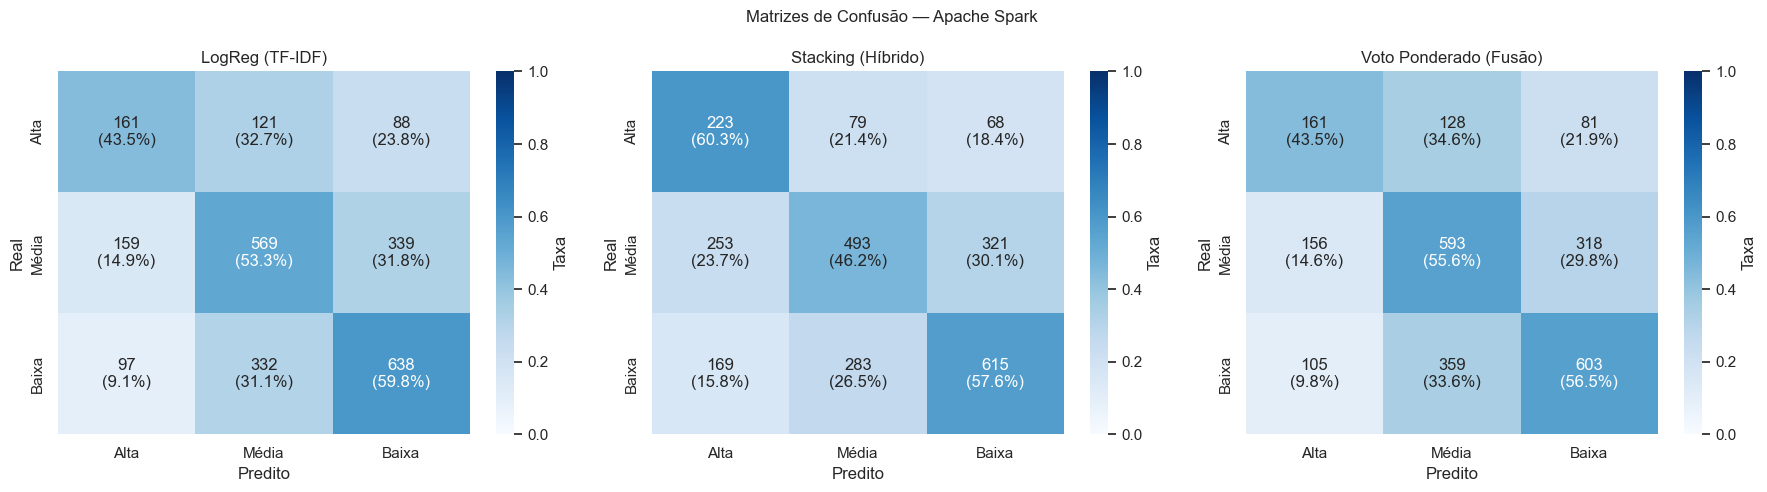

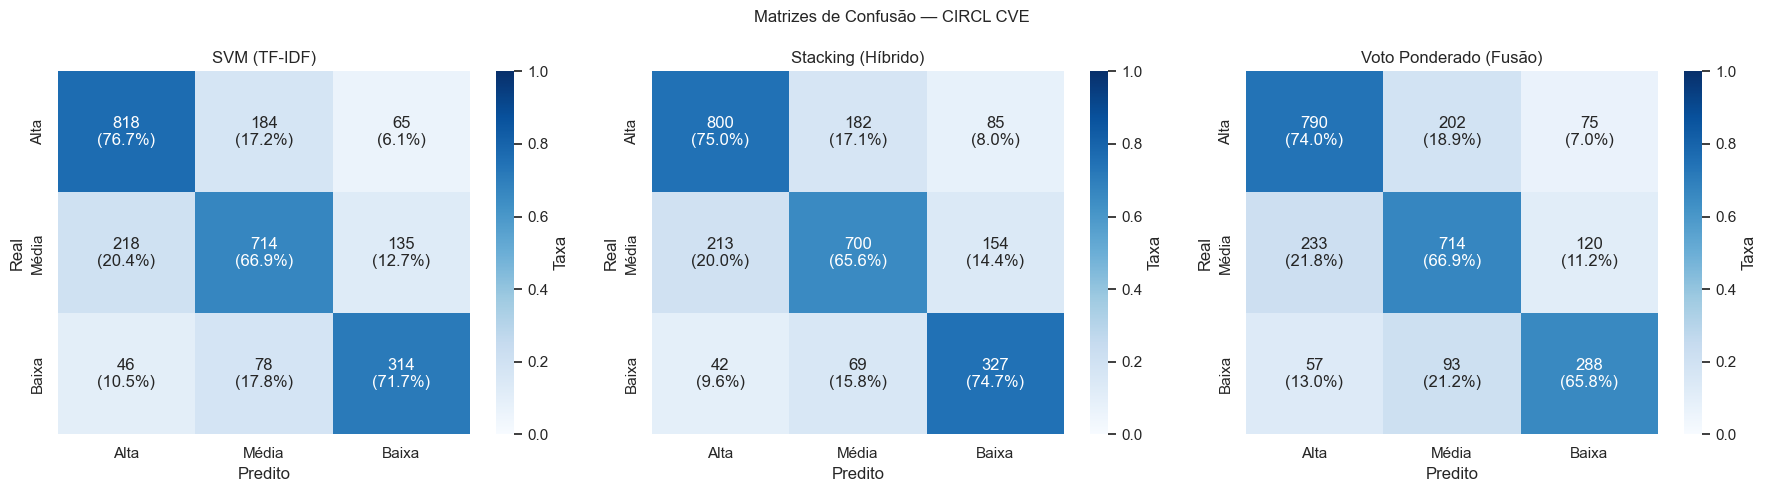

In [28]:
# ── Matrizes de confusão: melhor baseline vs Stacking vs Voto Ponderado ──────

def best_baseline(results):
    return max(results.items(), key=lambda kv: kv[1]['summary'].loc['mean','F1-macro'])


def plot_confusion_triplet(res_base, nome_base, res_stack, res_vote, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Matrizes de Confusão — {dataset_name}', fontsize=12)

    panels = [(axes[0], res_base, nome_base),
              (axes[1], res_stack, 'Stacking (Híbrido)'),
              (axes[2], res_vote,  'Voto Ponderado (Fusão)')]
    for ax, res, nome in panels:
        cm      = confusion_matrix(res['y_true'], res['y_pred'], labels=CLASSES)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot   = [[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})' for j in range(3)] for i in range(3)]
        sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Taxa'})
        ax.set_title(nome)
        ax.set_xlabel('Predito'); ax.set_ylabel('Real')

    plt.tight_layout()
    fname = f'confusion_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


nome_bst_s, res_bst_s = best_baseline(results_spark)
nome_bst_c, res_bst_c = best_baseline(results_circl)
print(f'Melhor baseline Spark: {nome_bst_s}')
print(f'Melhor baseline CIRCL: {nome_bst_c}')

plot_confusion_triplet(res_bst_s, nome_bst_s, result_stack_spark, result_voting_spark, 'Apache Spark')
plot_confusion_triplet(res_bst_c, nome_bst_c, result_stack_circl, result_voting_circl, 'CIRCL CVE')

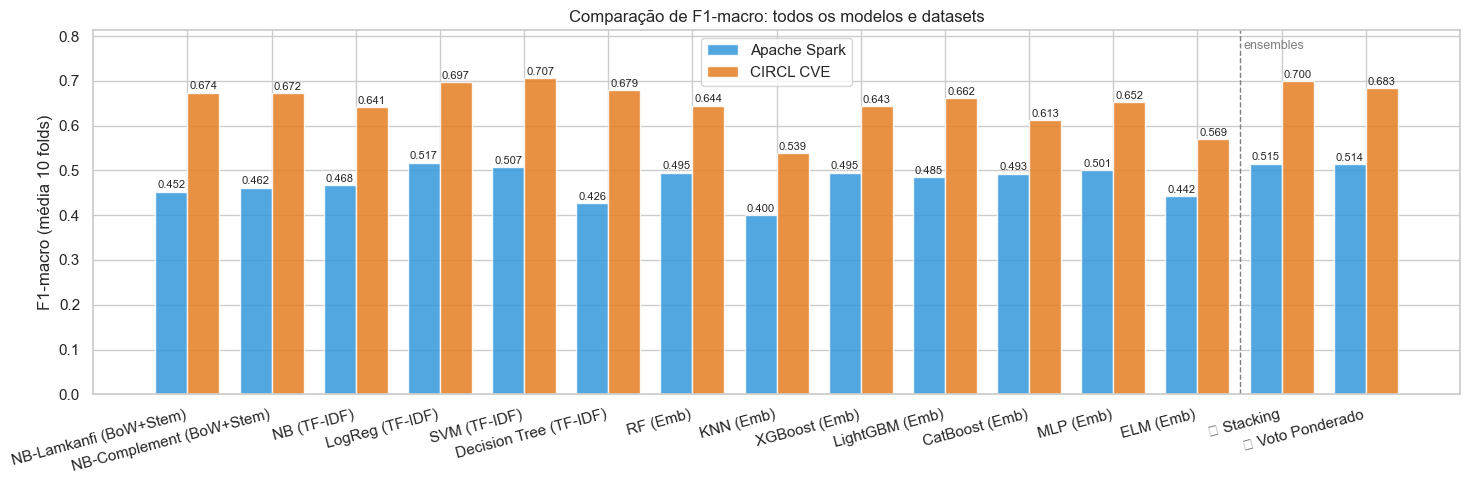

In [29]:
# ── Gráfico de barras comparativo: F1-macro por modelo e dataset ──────────────

def plot_f1_comparison(results_spark, results_circl, stack_s, stack_c, vote_s, vote_c):
    modelos = list(results_spark.keys()) + ['★ Stacking', '⬥ Voto Ponderado']
    f1_spark = [results_spark[n]['summary'].loc['mean','F1-macro'] for n in results_spark]
    f1_spark += [stack_s['summary'].loc['mean','F1-macro'],
                 vote_s['summary'].loc['mean','F1-macro']]
    f1_circl = [results_circl[n]['summary'].loc['mean','F1-macro'] for n in results_circl]
    f1_circl += [stack_c['summary'].loc['mean','F1-macro'],
                 vote_c['summary'].loc['mean','F1-macro']]

    x = np.arange(len(modelos)); w = 0.38
    fig, ax = plt.subplots(figsize=(15, 5))
    b1 = ax.bar(x - w/2, f1_spark, w, label='Apache Spark', color='#3498db', alpha=0.85)
    b2 = ax.bar(x + w/2, f1_circl, w, label='CIRCL CVE',    color='#e67e22', alpha=0.85)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(modelos, rotation=15, ha='right')
    ax.set_ylabel('F1-macro (média 10 folds)')
    ax.set_title('Comparação de F1-macro: todos os modelos e datasets')
    ax.set_ylim(0, max(max(f1_spark), max(f1_circl)) * 1.15)
    ax.legend()
    ax.axvline(len(modelos) - 2.5, color='gray', linestyle='--', linewidth=1)
    ax.text(len(modelos) - 2.5 + 0.05, ax.get_ylim()[1]*0.95, 'ensembles',
            fontsize=9, color='gray')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'f1_comparacao_geral.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_f1_comparison(results_spark, results_circl,
                   result_stack_spark, result_stack_circl,
                   result_voting_spark, result_voting_circl)

---
## Seção 11 — Comparação Final: Teste de Wilcoxon

Wilcoxon signed-rank (não-paramétrico, pareado) fold-a-fold — escolhido porque com
n=10 folds não podemos verificar normalidade dos resíduos para o t-test. Realizamos
três comparações bicaudais (H₀: desempenhos equivalentes):

1. **Stacking vs melhor baseline** — o meta-learning supera o melhor modelo isolado?
2. **Voto Ponderado (Fusão) vs melhor baseline** — a fusão simples já supera o melhor
   isolado?
3. **Stacking vs Voto Ponderado** — sobre os **mesmos** base-learners, o meta-learning
   realmente bate a fusão? (a questão científica central que motiva adicionar a Fusão).


=== Wilcoxon — Apache Spark ===
Stacking vs LogReg (TF-IDF) | métrica: F1-macro
  Stacking:  [0.4784 0.5091 0.4941 0.5058 0.5334 0.5486 0.5041 0.5059 0.5739 0.4998]
  LogReg (TF-IDF):  [0.4739 0.4618 0.4624 0.5366 0.5269 0.5502 0.5475 0.5248 0.5786 0.5072]
  Diferença: [ 0.0045  0.0473  0.0317 -0.0308  0.0065 -0.0016 -0.0435 -0.0189 -0.0047
 -0.0075]
  Stacking média:  0.5153 ± 0.0270
  LogReg (TF-IDF) média:  0.5170 ± 0.0379
  Melhora média:   -0.0017

  Wilcoxon: W=24.000, p=0.7695
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


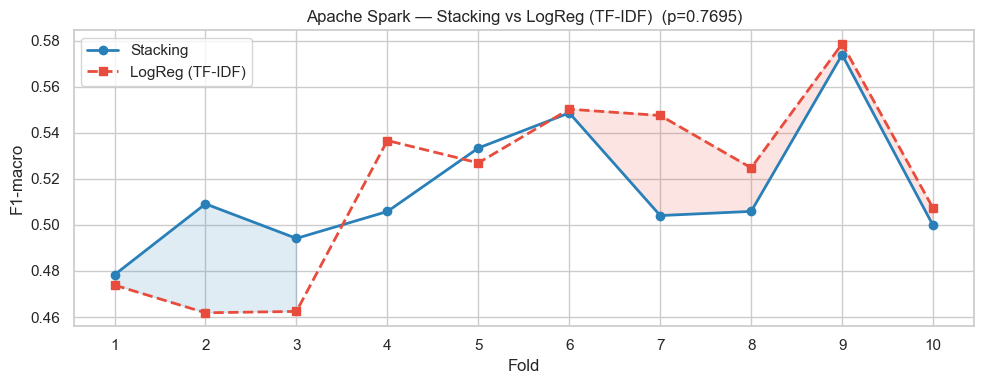


=== Wilcoxon — CIRCL CVE ===
Stacking vs SVM (TF-IDF) | métrica: F1-macro
  Stacking:  [0.7448 0.6881 0.6817 0.6816 0.682  0.6645 0.7076 0.7426 0.7153 0.6888]
  SVM (TF-IDF):  [0.7464 0.6772 0.682  0.6821 0.6789 0.6697 0.7326 0.7439 0.7362 0.7168]
  Diferença: [-0.0016  0.011  -0.0003 -0.0006  0.0031 -0.0051 -0.0249 -0.0013 -0.0209
 -0.028 ]
  Stacking média:  0.6997 ± 0.0258
  SVM (TF-IDF) média:  0.7066 ± 0.0297
  Melhora média:   -0.0069

  Wilcoxon: W=12.000, p=0.1309
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


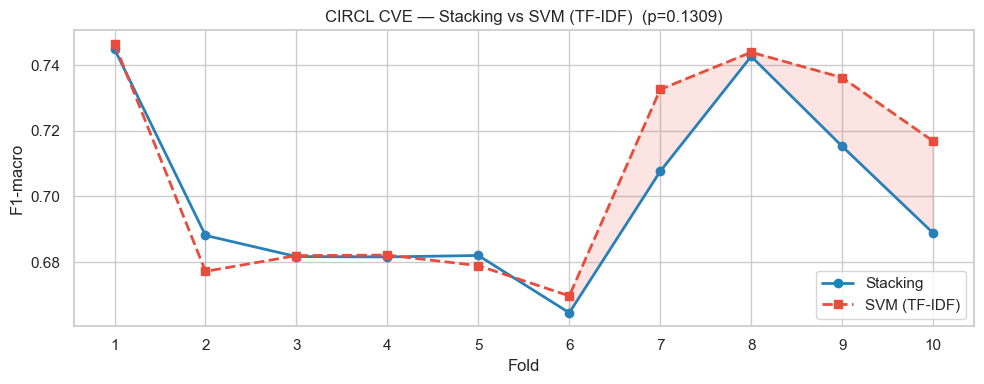


=== Wilcoxon — Apache Spark ===
Voto Ponderado vs LogReg (TF-IDF) | métrica: F1-macro
  Voto Ponderado:  [0.4969 0.5003 0.4939 0.4931 0.5569 0.5182 0.4972 0.5043 0.5749 0.5025]
  LogReg (TF-IDF):  [0.4739 0.4618 0.4624 0.5366 0.5269 0.5502 0.5475 0.5248 0.5786 0.5072]
  Diferença: [ 0.023   0.0385  0.0315 -0.0435  0.03   -0.0321 -0.0503 -0.0205 -0.0037
 -0.0048]
  Voto Ponderado média:  0.5138 ± 0.0272
  LogReg (TF-IDF) média:  0.5170 ± 0.0379
  Melhora média:   -0.0032

  Wilcoxon: W=23.000, p=0.6953
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


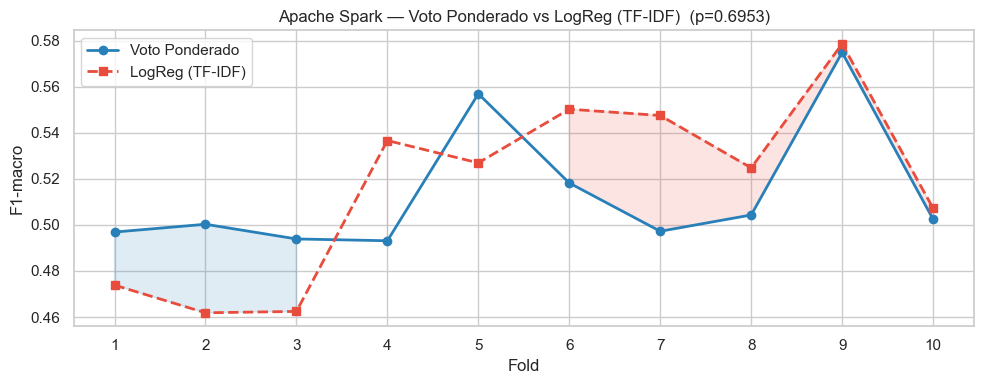


=== Wilcoxon — CIRCL CVE ===
Voto Ponderado vs SVM (TF-IDF) | métrica: F1-macro
  Voto Ponderado:  [0.671  0.6512 0.6672 0.704  0.6605 0.6687 0.6724 0.7253 0.7092 0.7019]
  SVM (TF-IDF):  [0.7464 0.6772 0.682  0.6821 0.6789 0.6697 0.7326 0.7439 0.7362 0.7168]
  Diferença: [-0.0755 -0.026  -0.0147  0.0219 -0.0184 -0.001  -0.0601 -0.0186 -0.0269
 -0.015 ]
  Voto Ponderado média:  0.6832 ± 0.0234
  SVM (TF-IDF) média:  0.7066 ± 0.0297
  Melhora média:   -0.0234

  Wilcoxon: W=6.000, p=0.0273
  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA
  Voto Ponderado é PIOR que SVM (TF-IDF).


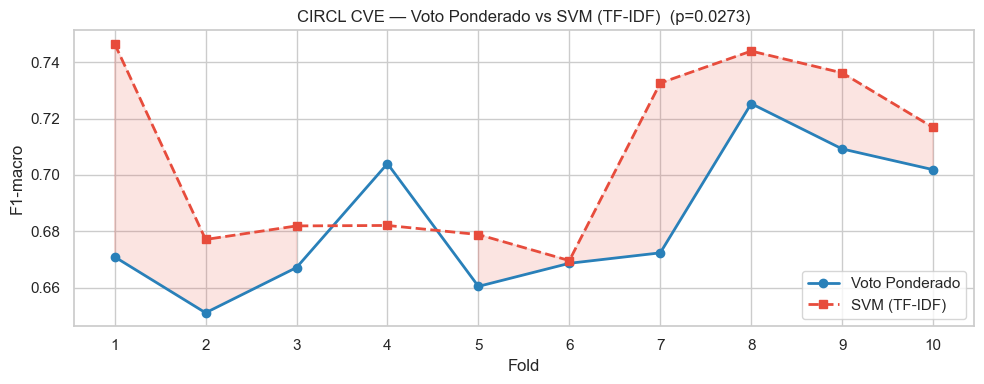


=== Wilcoxon — Apache Spark ===
Stacking vs Voto Ponderado | métrica: F1-macro
  Stacking:  [0.4784 0.5091 0.4941 0.5058 0.5334 0.5486 0.5041 0.5059 0.5739 0.4998]
  Voto Ponderado:  [0.4969 0.5003 0.4939 0.4931 0.5569 0.5182 0.4972 0.5043 0.5749 0.5025]
  Diferença: [-0.0185  0.0089  0.0002  0.0127 -0.0236  0.0304  0.0068  0.0016 -0.001
 -0.0027]
  Stacking média:  0.5153 ± 0.0270
  Voto Ponderado média:  0.5138 ± 0.0272
  Melhora média:   +0.0015

  Wilcoxon: W=23.000, p=0.6953
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


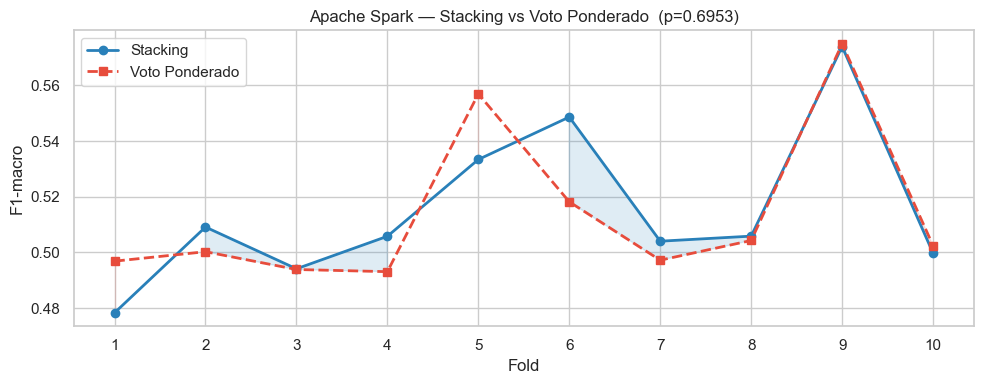


=== Wilcoxon — CIRCL CVE ===
Stacking vs Voto Ponderado | métrica: F1-macro
  Stacking:  [0.7448 0.6881 0.6817 0.6816 0.682  0.6645 0.7076 0.7426 0.7153 0.6888]
  Voto Ponderado:  [0.671  0.6512 0.6672 0.704  0.6605 0.6687 0.6724 0.7253 0.7092 0.7019]
  Diferença: [ 0.0739  0.0369  0.0144 -0.0225  0.0215 -0.0042  0.0352  0.0174  0.006
 -0.013 ]
  Stacking média:  0.6997 ± 0.0258
  Voto Ponderado média:  0.6832 ± 0.0234
  Melhora média:   +0.0166

  Wilcoxon: W=11.000, p=0.1055
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


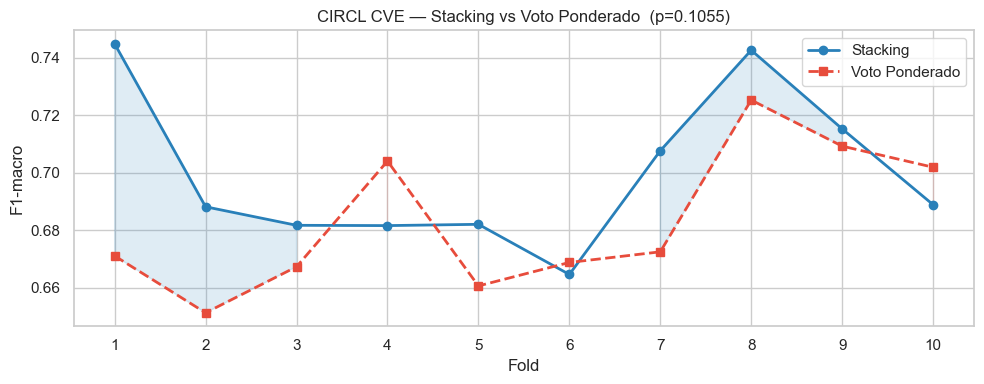


=== Wilcoxon — Apache Spark ===
Comb. Dinâmica vs LogReg (TF-IDF) | métrica: F1-macro
  Comb. Dinâmica:  [0.3323 0.3712 0.3292 0.3831 0.294  0.3518 0.4005 0.3966 0.3247 0.3637]
  LogReg (TF-IDF):  [0.4739 0.4618 0.4624 0.5366 0.5269 0.5502 0.5475 0.5248 0.5786 0.5072]
  Diferença: [-0.1416 -0.0907 -0.1332 -0.1536 -0.233  -0.1985 -0.147  -0.1282 -0.2539
 -0.1435]
  Comb. Dinâmica média:  0.3547 ± 0.0328
  LogReg (TF-IDF) média:  0.5170 ± 0.0379
  Melhora média:   -0.1623

  Wilcoxon: W=0.000, p=0.0020
  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA
  Comb. Dinâmica é PIOR que LogReg (TF-IDF).


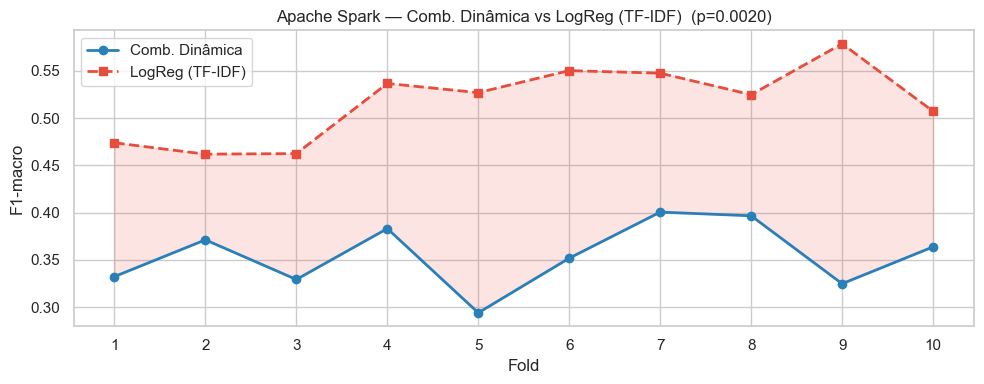


=== Wilcoxon — CIRCL CVE ===
Comb. Dinâmica vs SVM (TF-IDF) | métrica: F1-macro
  Comb. Dinâmica:  [0.3197 0.3413 0.3604 0.3512 0.3311 0.3514 0.3367 0.358  0.3011 0.3724]
  SVM (TF-IDF):  [0.7464 0.6772 0.682  0.6821 0.6789 0.6697 0.7326 0.7439 0.7362 0.7168]
  Diferença: [-0.4268 -0.3359 -0.3216 -0.3309 -0.3478 -0.3183 -0.3959 -0.3859 -0.4351
 -0.3445]
  Comb. Dinâmica média:  0.3423 ± 0.0200
  SVM (TF-IDF) média:  0.7066 ± 0.0297
  Melhora média:   -0.3642

  Wilcoxon: W=0.000, p=0.0020
  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA
  Comb. Dinâmica é PIOR que SVM (TF-IDF).


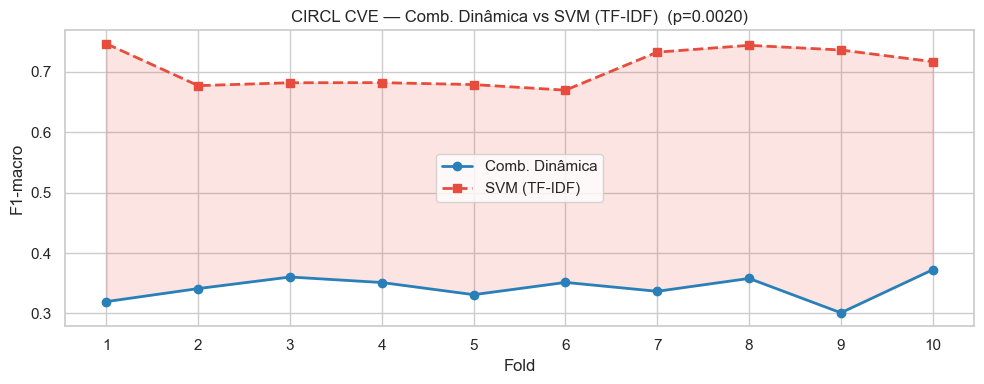


=== Wilcoxon — Apache Spark ===
Stacking vs Comb. Dinâmica | métrica: F1-macro
  Stacking:  [0.4784 0.5091 0.4941 0.5058 0.5334 0.5486 0.5041 0.5059 0.5739 0.4998]
  Comb. Dinâmica:  [0.3323 0.3712 0.3292 0.3831 0.294  0.3518 0.4005 0.3966 0.3247 0.3637]
  Diferença: [0.1461 0.138  0.1649 0.1228 0.2394 0.1969 0.1035 0.1093 0.2492 0.136 ]
  Stacking média:  0.5153 ± 0.0270
  Comb. Dinâmica média:  0.3547 ± 0.0328
  Melhora média:   +0.1606

  Wilcoxon: W=0.000, p=0.0020
  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA
  Stacking é MELHOR que Comb. Dinâmica.


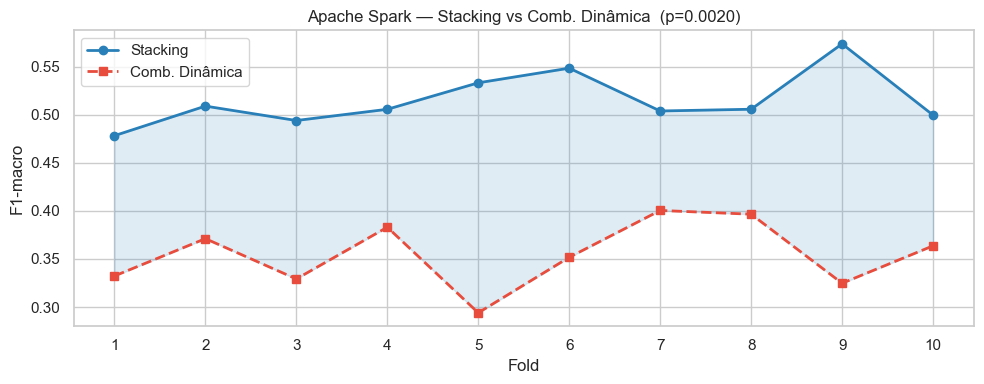


=== Wilcoxon — CIRCL CVE ===
Stacking vs Comb. Dinâmica | métrica: F1-macro
  Stacking:  [0.7448 0.6881 0.6817 0.6816 0.682  0.6645 0.7076 0.7426 0.7153 0.6888]
  Comb. Dinâmica:  [0.3197 0.3413 0.3604 0.3512 0.3311 0.3514 0.3367 0.358  0.3011 0.3724]
  Diferença: [0.4252 0.3469 0.3213 0.3303 0.3509 0.3131 0.3709 0.3846 0.4141 0.3165]
  Stacking média:  0.6997 ± 0.0258
  Comb. Dinâmica média:  0.3423 ± 0.0200
  Melhora média:   +0.3574

  Wilcoxon: W=0.000, p=0.0020
  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA
  Stacking é MELHOR que Comb. Dinâmica.


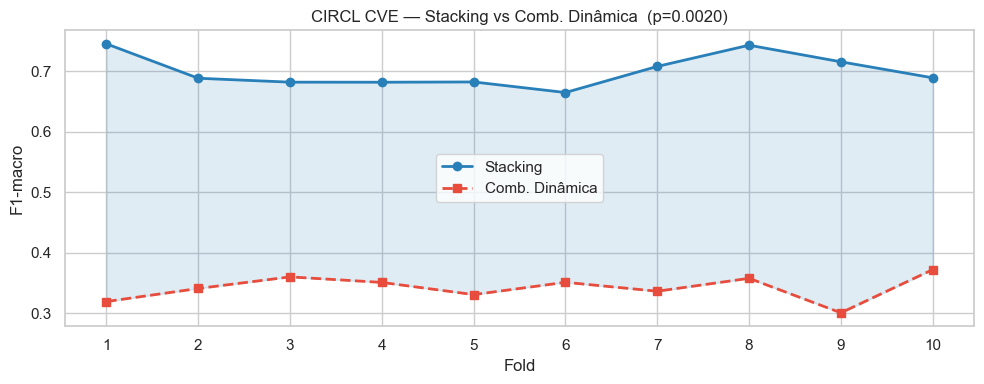

In [30]:
def teste_wilcoxon(res_a, res_b, nome_b, dataset_name, nome_a='Stacking',
                   metrica='F1-macro'):
    """Wilcoxon pareado fold-a-fold entre dois sistemas (res_a vs res_b).

    Genérico: `nome_a` rotula o sistema A (default 'Stacking') para reaproveitar
    a função tanto em Stacking-vs-baseline quanto em Voto-vs-baseline e
    Stacking-vs-Voto.
    """
    f1_a = res_a['folds'][metrica].values
    f1_b = res_b['folds'][metrica].values
    diff = f1_a - f1_b

    print(f'\n=== Wilcoxon — {dataset_name} ===')
    print(f'{nome_a} vs {nome_b} | métrica: {metrica}')
    print(f'  {nome_a}:  {f1_a.round(4)}')
    print(f'  {nome_b}:  {f1_b.round(4)}')
    print(f'  Diferença: {diff.round(4)}')
    print(f'  {nome_a} média:  {f1_a.mean():.4f} ± {f1_a.std():.4f}')
    print(f'  {nome_b} média:  {f1_b.mean():.4f} ± {f1_b.std():.4f}')
    print(f'  Melhora média:   {diff.mean():+.4f}')

    if np.all(diff == 0):
        print('  AVISO: diferenças todas zero — Wilcoxon não aplicável.')
        return

    stat, p = wilcoxon(f1_a, f1_b, alternative='two-sided')
    print(f'\n  Wilcoxon: W={stat:.3f}, p={p:.4f}')
    if p < 0.05:
        print(f'  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA')
        print(f'  {nome_a} é {"MELHOR" if diff.mean() > 0 else "PIOR"} que {nome_b}.')
    else:
        print(f'  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.')

    # Gráfico fold-a-fold
    fig, ax = plt.subplots(figsize=(10, 4))
    folds = range(1, len(f1_a) + 1)
    ax.plot(folds, f1_a, 'o-', label=nome_a, color='#2980b9', linewidth=2)
    ax.plot(folds, f1_b, 's--', label=nome_b, color='#e74c3c', linewidth=2)
    ax.fill_between(folds, f1_a, f1_b,
                    where=(f1_a >= f1_b), alpha=0.15, color='#2980b9')
    ax.fill_between(folds, f1_a, f1_b,
                    where=(f1_a < f1_b), alpha=0.15, color='#e74c3c')
    ax.set_xticks(list(folds))
    ax.set_xlabel('Fold'); ax.set_ylabel(metrica)
    ax.set_title(f'{dataset_name} — {nome_a} vs {nome_b}  (p={p:.4f})')
    ax.legend()
    plt.tight_layout()
    slug_a = nome_a.lower().replace(" ", "_")
    slug_b = nome_b.lower().replace(" ", "_")
    fname = f'wilcoxon_{dataset_name.lower().replace(" ","_")}_{slug_a}_vs_{slug_b}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


# ── 1) Stacking vs melhor baseline ───────────────────────────────────────────
teste_wilcoxon(result_stack_spark, res_bst_s, nome_bst_s, 'Apache Spark', nome_a='Stacking')
teste_wilcoxon(result_stack_circl, res_bst_c, nome_bst_c, 'CIRCL CVE',    nome_a='Stacking')

# ── 2) Voto Ponderado (Fusão) vs melhor baseline ─────────────────────────────
teste_wilcoxon(result_voting_spark, res_bst_s, nome_bst_s, 'Apache Spark', nome_a='Voto Ponderado')
teste_wilcoxon(result_voting_circl, res_bst_c, nome_bst_c, 'CIRCL CVE',    nome_a='Voto Ponderado')

# ── 3) Meta-learning vs Fusão: Stacking vs Voto Ponderado (mesmos base-learners) ─
teste_wilcoxon(result_stack_spark, result_voting_spark, 'Voto Ponderado', 'Apache Spark', nome_a='Stacking')
teste_wilcoxon(result_stack_circl, result_voting_circl, 'Voto Ponderado', 'CIRCL CVE',    nome_a='Stacking')

# ── 4) Combinação Dinâmica vs melhor baseline ─────────────────────────────────
teste_wilcoxon(result_comb_spark, res_bst_s, nome_bst_s, 'Apache Spark', nome_a='Comb. Dinâmica')
teste_wilcoxon(result_comb_circl, res_bst_c, nome_bst_c, 'CIRCL CVE',    nome_a='Comb. Dinâmica')

# ── 5) Stacking vs Combinação Dinâmica ────────────────────────────────────────
teste_wilcoxon(result_stack_spark, result_comb_spark, 'Comb. Dinâmica', 'Apache Spark', nome_a='Stacking')
teste_wilcoxon(result_stack_circl, result_comb_circl, 'Comb. Dinâmica', 'CIRCL CVE',    nome_a='Stacking')

---
## Seção 12 — Conclusão

### Decisões de design justificadas

| Decisão | Justificativa |
|---|---|
| F1-macro como métrica principal | Equânime entre classes; acurácia é enganosa com desbalanceamento |
| Pré-processamento por representação | TF-IDF: stopwords + Porter stemming (`_lamkanfi_tokenizer`, alinhado a Lamkanfi/Spanos); embeddings: texto bruto |
| SMOTE **dentro** do fold | Evita data leakage — bug clássico de trabalhos que aplicam SMOTE antes do split |
| Undersampling real-first | Preserva amostras reais da classe rara antes do SMOTE |
| Stacking com OOF | Evita leakage nas meta-features |
| Base-learners selecionados via Nemenyi | Composição não fixada a priori — emerge dos dados (Seção 8.1) |
| XGBoost + LightGBM | Cumpre requisito de modelos não-sklearn |
| Friedman + Nemenyi | Comparação robusta entre múltiplos modelos (Demšar, 2006) |
| Wilcoxon | Comparação pareada final não-paramétrica |
| Dois datasets | Avalia generalização além do domínio original de Lamkanfi |

### Resultados estatísticos — Wilcoxon pareado (α = 0.05)

> ⚠️ **Valores da execução anterior** (antes de: stemming no TF-IDF, NB-Lamkanfi, ELM, PCA no KNN, e exclusão de XGB/LGBM do stacking). Recalcular após re-rodar a Seção 11.

| Comparação | Apache Spark | CIRCL CVE |
|---|---|---|
| Stacking vs SVM (TF-IDF) | p = 0.4922 — não significativo | p = 0.3223 — não significativo |
| Voto Ponderado vs SVM (TF-IDF) | p = 0.1055 — não significativo | p = 0.0195 — **SVM superior** |
| Stacking vs Voto Ponderado | p = 0.4922 — não significativo | p = 0.0840 — não significativo |

Os testes de Wilcoxon não confirmam superioridade estatística dos ensembles sobre o SVM com TF-IDF. O único resultado significativo (CIRCL CVE, Voto Ponderado vs SVM, p = 0.0195) aponta na direção inversa: o baseline supera o ensemble. Isso é um **resultado negativo honesto**: sistemas mais complexos não necessariamente superam baselines fortes com representação bem ajustada.

### Alinhamento com a literatura

Os resultados são consistentes com o estado da arte para classificação de severidade de 3 classes:

- **Lamkanfi (2010)**: precisão/recall de 0.65–0.75 para classificação *binária* com NB e **BoW (frequência bruta) + stemming** (CountVectorizer, *não* TF-IDF). Nosso SVM (TF-IDF) atinge F1-macro ≈ 0.52 (Spark) e 0.70 (CIRCL) para 3 classes — comparável após ajuste pela maior dificuldade do problema tri-classe. Alinhamento metodológico: usamos o mesmo pré-processamento de Lamkanfi (stopwords + Porter stemming) nos modelos TF-IDF, mais TF-IDF sublinear sobre o BoW original.
- **Kukkar/Umer (2019, Sensors)**: acurácias de 93–97% com CNN+RF. Não comparável: dataset diferente (qualidade de software), features estruturadas adicionais, e acurácia em dados desbalanceados é enganosa — os autores não reportam F1-macro.
- **Spanos (2018)**: predição multi-target de CVSS com regressão; métricas e abordagem distintas, sem comparação direta.

A variação entre Spark (F1 ≈ 0.52) e CIRCL (F1 ≈ 0.70) evidencia a dificuldade inerente: rótulos de prioridade Jira são mais subjetivos que os scores CVSS do NVD/CIRCL.

### Limitações

1. **Mapeamento de rótulos:** prioridade Jira é subjetiva; CVSS pode ser revisado retroativamente
2. **Generalização limitada:** Spark é um único projeto open-source; CIRCL é um dataset público pequeno
3. **Custo computacional:** nested CV (10 × 5 folds × N base-learners) requer muita CPU/GPU
4. **Folds não totalmente independentes:** Wilcoxon e Friedman podem superestimar significância
5. **Combinação Dinâmica não executada:** implementada (Seção 9.2) mas ainda sem resultado 10-fold consolidado

### Próximos passos

- Fine-tuning do Qwen3 nos dados de bug reports (representação específica do domínio)
- Integração de features estruturadas (componente, versão, histórico do reportador)
- Avaliação cross-project: treinar no Spark, testar no CIRCL e vice-versa
- Comparar com/sem stemming nos modelos TF-IDF (isolar a variável metodológica, agora que o stemming está ativo)
- Deploy em sistema de triagem automática com feedback loop